=== ANÁLISE DE CAMPANHA DE PERFURAÇÃO ===
Configure os parâmetros da análise:



Número de poços:  5
Custo de perfuração por poço (padrão 0):  2
Força da correlação entre poços (0-1, padrão 0.3):  0.6
Número de simulações Monte Carlo (padrão 1000):  2000



INICIANDO ANÁLISE PARA 5 POÇOS
Custo de perfuração: 2.0
Correlação: 0.6
Simulações: 2000

PROBABILIDADES MARGINAIS ALEATÓRIAS:
  Poço 0: [0.35697954 0.29268879 0.26806256 0.08226911] (EV: -4.87, Sucesso: 35.0%)
  Poço 1: [0.38703775 0.13543857 0.23746929 0.24005438] (EV: -2.96, Sucesso: 47.8%)
  Poço 2: [0.0256491  0.21380486 0.70141902 0.05912703] (EV: 0.77, Sucesso: 76.1%)
  Poço 3: [0.08384137 0.05197811 0.34783608 0.51634444] (EV: 3.80, Sucesso: 86.4%)
  Poço 4: [0.22483085 0.29855622 0.28527621 0.19133672] (EV: -2.40, Sucesso: 47.7%)
Calculando política ótima com SDP...
Simulando campanhas anteriores...
Simulando campanhas sequenciais...

Tempo de análise: 3.36 segundos

RESULTADOS PRINCIPAIS
EV Sequencial (SDP determinístico): 4.57
EV Anterior (simulado): 4.29
EV Sequencial (simulado): 4.55
VOI (simulado): 0.27
Melhoria: 6.3%

POLÍTICA ÓTIMA:
  Primeira ação: Perfurar poço 3


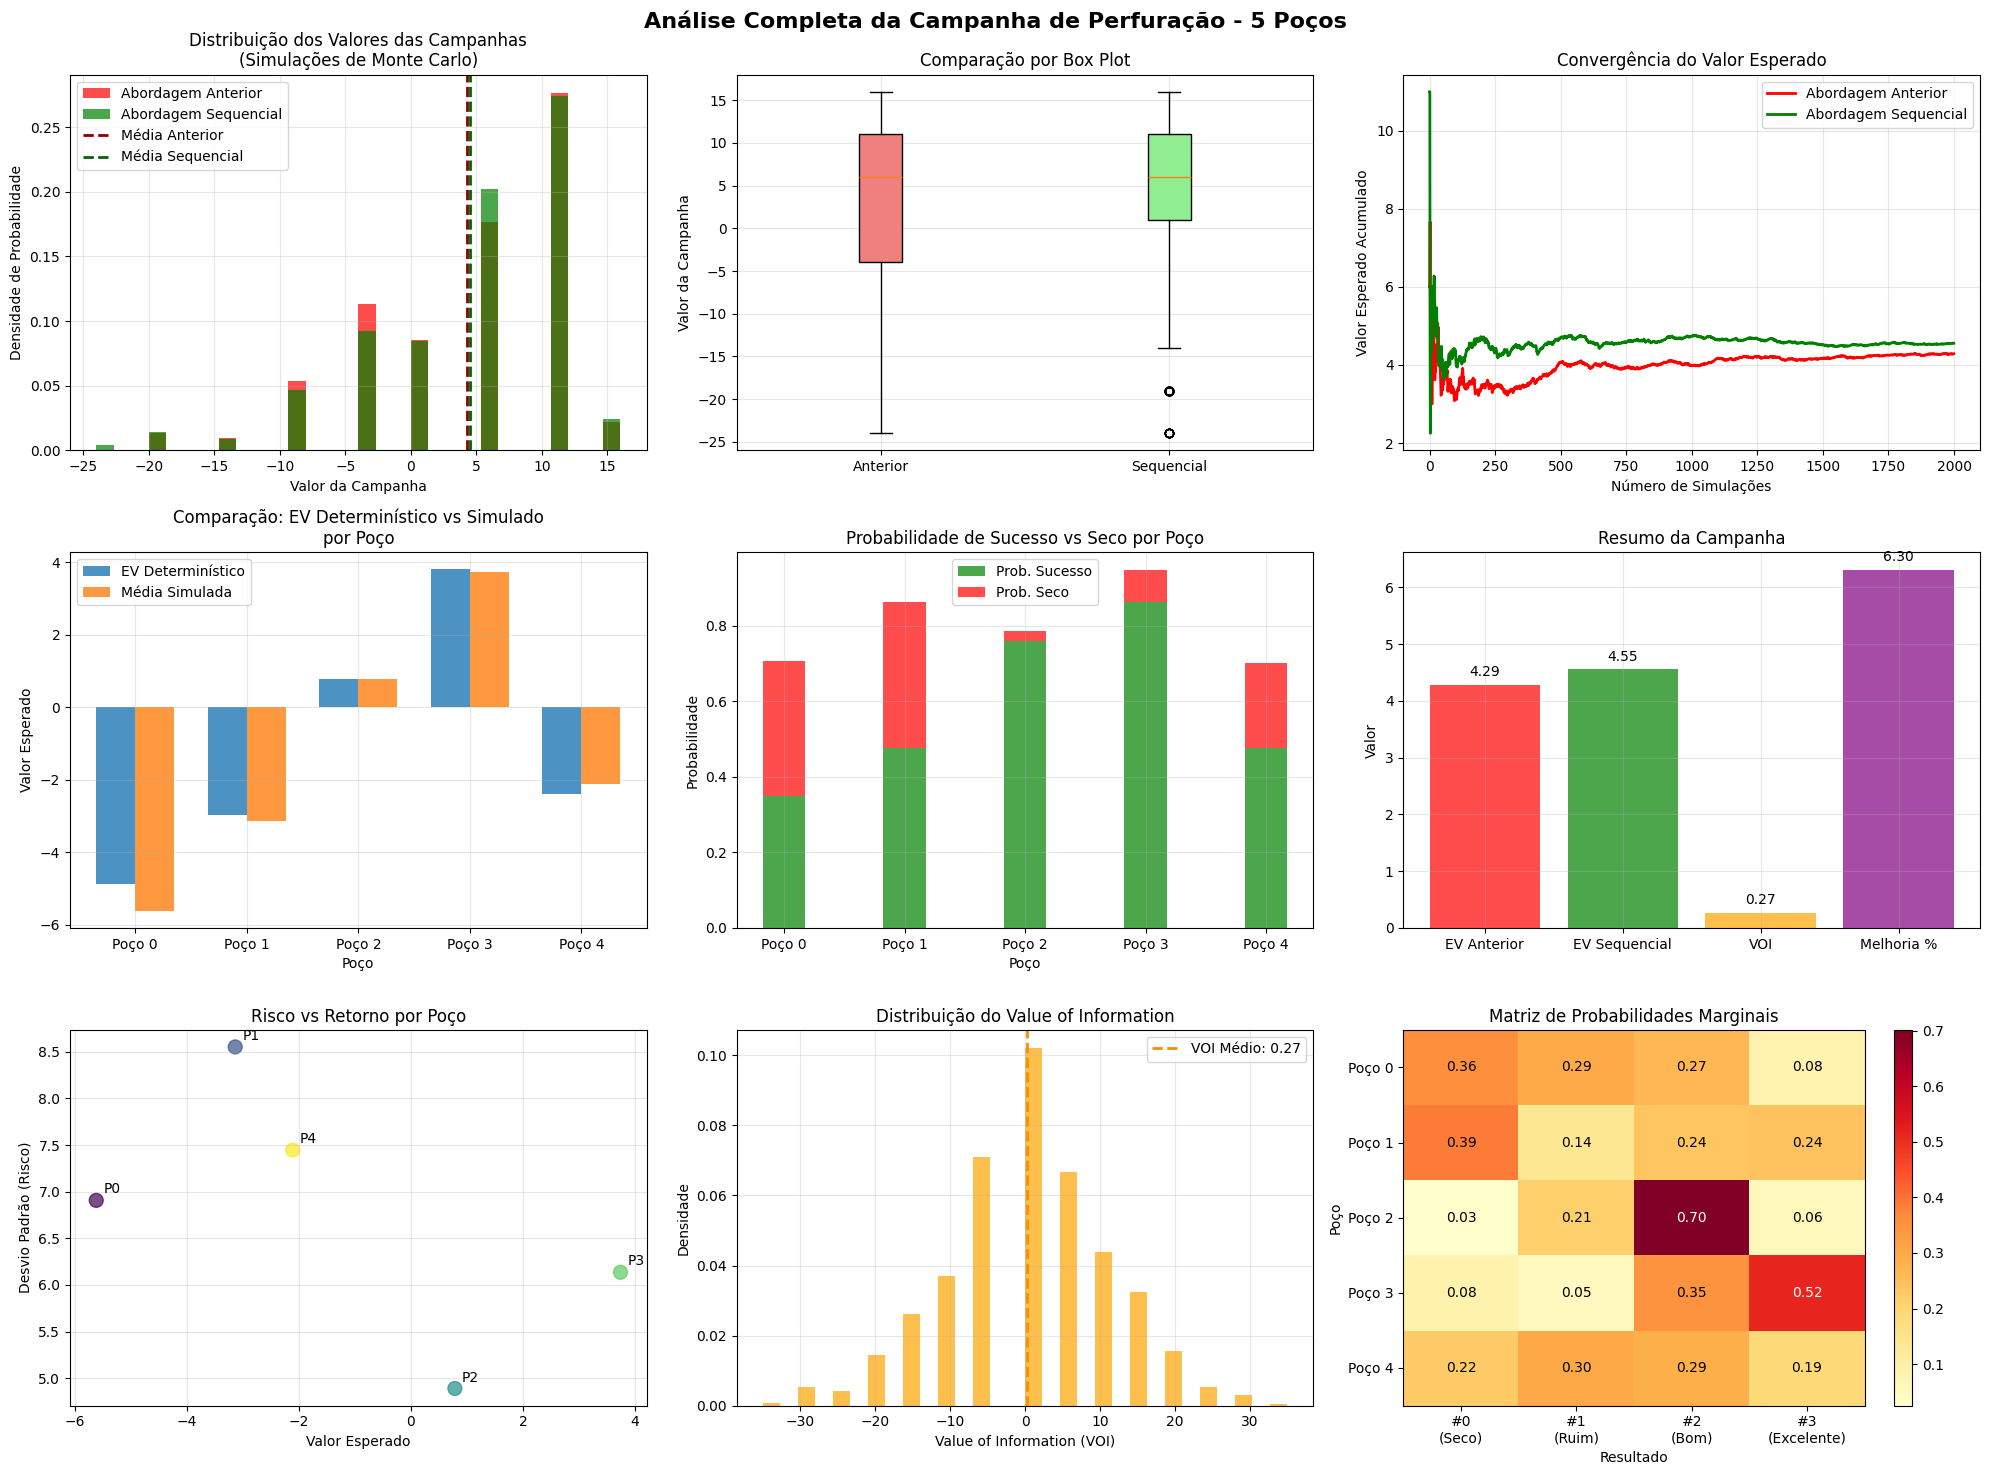


ESTATÍSTICAS DETALHADAS DAS SIMULAÇÕES

ABORDAGEM ANTERIOR (2000 simulações):
  Média: 4.29 ± 7.73
  Mediana: 6.00
  Intervalo: [-24.00, 16.00]
  5º percentil: -9.00
  95º percentil: 11.00

ABORDAGEM SEQUENCIAL (2000 simulações):
  Média: 4.55 ± 7.78
  Mediana: 6.00
  Intervalo: [-24.00, 16.00]
  5º percentil: -9.00
  95º percentil: 11.00

VALUE OF INFORMATION (VOI):
  VOI médio: 0.27
  Melhoria relativa: 6.3%
  Probabilidade de VOI positivo: 39.1%

ANÁLISE POR POÇO:
  Poço 0: EV=-4.87, Sucesso=35.0%, Seco=35.7%
  Poço 1: EV=-2.96, Sucesso=47.8%, Seco=38.7%
  Poço 2: EV=0.77, Sucesso=76.1%, Seco=2.6%
  Poço 3: EV=3.80, Sucesso=86.4%, Seco=8.4%
  Poço 4: EV=-2.40, Sucesso=47.7%, Seco=22.5%

ANÁLISE CONCLUÍDA!


In [130]:
import numpy as np
import itertools
from typing import List, Dict, Tuple, Any
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class SequentialDrillingSDP:
    def __init__(self, num_wells: int, revenues: List[float], drilling_cost: float = 0,
                 marginal_probs: List[np.ndarray] = None, correlation_strength: float = 0.3,
                 num_simulations: int = 1000, random_seed: int = None):
        """
        Inicializa o solver SDP para perfuração sequencial com simulações estocásticas
        """
        self.num_wells = num_wells
        self.revenues = revenues
        self.drilling_cost = drilling_cost
        self.num_states = 4
        self.correlation_strength = correlation_strength
        self.num_simulations = num_simulations
        self.random_seed = random_seed if random_seed is not None else int(time.time())
        
        # Inicializar random state
        self.rng = np.random.RandomState(self.random_seed)
        
        # Inicializar probabilidades
        self.marginal_probs = marginal_probs if marginal_probs is not None else self._initialize_random_marginal_probs()
        self.jpd = self._initialize_jpd_with_correlation()
        
        # Cache para otimização
        self.cache = {}
        
    def _initialize_random_marginal_probs(self) -> List[np.ndarray]:
        """Inicializa probabilidades marginais aleatórias para cada poço"""
        probs = []
        for i in range(self.num_wells):
            # Gerar probabilidades aleatórias diferentes para cada execução
            alpha = self.rng.uniform(0.5, 3, 4)
            p = self.rng.dirichlet(alpha)
            probs.append(p)
        return probs
    
    def _initialize_jpd_with_correlation(self) -> np.ndarray:
        """Inicializa JPD com correlação espacial entre poços"""
        positions = np.linspace(0, 1, self.num_wells)
        covariance_matrix = np.zeros((self.num_wells, self.num_wells))
        
        for i in range(self.num_wells):
            for j in range(self.num_wells):
                distance = abs(positions[i] - positions[j])
                covariance_matrix[i, j] = np.exp(-distance / 0.3) * self.correlation_strength
        
        jpd = np.ones([self.num_states] * self.num_wells)
        
        for indices in itertools.product(*[range(self.num_states) for _ in range(self.num_wells)]):
            prob = 1.0
            for well_idx, state in enumerate(indices):
                base_prob = self.marginal_probs[well_idx][state]
                
                correlation_factor = 1.0
                for other_idx, other_state in enumerate(indices):
                    if well_idx != other_idx:
                        if state == other_state:
                            correlation_factor += covariance_matrix[well_idx, other_idx] * 0.5
                
                adjusted_prob = base_prob * correlation_factor
                prob *= adjusted_prob
            
            jpd[indices] = max(0, prob)
        
        jpd /= jpd.sum()
        return jpd
    
    def sample_outcome(self, conditional_probs: np.ndarray) -> int:
        """Amostra um resultado baseado nas probabilidades condicionais"""
        return self.rng.choice(len(conditional_probs), p=conditional_probs)
    
    def simulate_prior_campaign(self) -> List[float]:
        """Simula múltiplas campanhas usando abordagem anterior (sem informação sequencial)"""
        campaign_values = []
        
        for _ in range(self.num_simulations):
            total_value = 0
            # Decidir quais poços perfurar baseado no EV marginal
            for well in range(self.num_wells):
                marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
                if marginal_ev > 0:
                    # Simular resultado real deste poço
                    outcome = self.sample_outcome(self.marginal_probs[well])
                    revenue = self.revenues[outcome] - self.drilling_cost
                    total_value += revenue
            
            campaign_values.append(total_value)
        
        return campaign_values
    
    def simulate_sequential_campaign(self, policy: Dict) -> List[float]:
        """Simula múltiplas campanhas usando abordagem sequencial ótima"""
        campaign_values = []
        
        for sim in range(self.num_simulations):
            # Usar uma seed diferente para cada simulação baseada na seed principal
            sim_rng = np.random.RandomState(self.random_seed + sim)
            total_value = 0
            perforated_wells = {}
            remaining_wells = list(range(self.num_wells))
            
            while remaining_wells:
                # Obter ação da política
                state_key = tuple(sorted(perforated_wells.items()))
                if state_key in policy and 'action' in policy[state_key]:
                    action = policy[state_key]['action']
                else:
                    # Sem política definida, parar campanha
                    break
                
                if action not in remaining_wells:
                    break
                
                # Obter probabilidades condicionais
                conditional_probs = self.get_conditional_probs(perforated_wells, [action])
                well_probs = conditional_probs[action]
                
                # Simular resultado real
                outcome = self._sample_outcome_with_rng(well_probs, sim_rng)
                revenue = self.revenues[outcome] - self.drilling_cost
                total_value += revenue
                
                # Atualizar estado
                perforated_wells[action] = outcome
                remaining_wells.remove(action)
                
                # Verificar se deve continuar (valor de continuação)
                next_state_key = tuple(sorted(perforated_wells.items()))
                if next_state_key in policy and policy[next_state_key].get('value', 0) <= 0:
                    break
            
            campaign_values.append(total_value)
        
        return campaign_values
    
    def _sample_outcome_with_rng(self, conditional_probs: np.ndarray, rng: np.random.RandomState) -> int:
        """Amostra um resultado usando um random state específico"""
        return rng.choice(len(conditional_probs), p=conditional_probs)
    
    def get_conditional_probs(self, observed_wells: Dict[int, int], remaining_wells: List[int]) -> Dict[int, np.ndarray]:
        """Calcula probabilidades condicionais para poços restantes dado observações"""
        cache_key = (tuple(sorted(observed_wells.items())), tuple(sorted(remaining_wells)))
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        if not observed_wells:
            result = {well: self.marginal_probs[well] for well in remaining_wells}
            self.cache[cache_key] = result
            return result
        
        conditional_probs = {}
        
        for target_well in remaining_wells:
            evidence_prob = 0
            target_probs = np.zeros(self.num_states)
            
            for target_state in range(self.num_states):
                full_state = [0] * self.num_wells
                
                for well, state in observed_wells.items():
                    full_state[well] = state
                
                full_state[target_well] = target_state
                prob = self.jpd[tuple(full_state)]
                target_probs[target_state] += prob
                evidence_prob += prob
            
            if evidence_prob > 0:
                target_probs /= evidence_prob
            
            conditional_probs[target_well] = target_probs
        
        self.cache[cache_key] = conditional_probs
        return conditional_probs
    
    def calculate_expected_value(self, conditional_probs: np.ndarray) -> float:
        """Calcula o valor esperado dado probabilidades condicionais"""
        ev = 0
        for state, prob in enumerate(conditional_probs):
            revenue = self.revenues[state] - self.drilling_cost
            ev += prob * revenue
        return ev
    
    def solve_sdp(self) -> Tuple[float, Dict]:
        """Resolve o problema usando Programação Dinâmica Estocástica"""
        
        def bellman(perforated_wells: Dict[int, int], remaining_wells: List[int]) -> Tuple[float, int]:
            if not remaining_wells:
                return 0, -1
            
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.cache:
                return self.cache[cache_key]
            
            conditional_probs = self.get_conditional_probs(perforated_wells, remaining_wells)
            
            best_value = 0
            best_action = -1
            
            for next_well in remaining_wells:
                well_ev = 0
                next_conditional_probs = conditional_probs[next_well]
                
                for outcome in range(self.num_states):
                    prob = next_conditional_probs[outcome]
                    if prob > 0:
                        revenue = self.revenues[outcome] - self.drilling_cost
                        
                        new_perforated = perforated_wells.copy()
                        new_perforated[next_well] = outcome
                        new_remaining = [w for w in remaining_wells if w != next_well]
                        
                        continuation_value, _ = bellman(new_perforated, new_remaining)
                        
                        total_value = revenue + continuation_value
                        well_ev += prob * total_value
                
                if well_ev > best_value:
                    best_value = well_ev
                    best_action = next_well
            
            self.cache[cache_key] = (best_value, best_action)
            return best_value, best_action
        
        initial_ev, first_action = bellman({}, list(range(self.num_wells)))
        policy = self._reconstruct_policy()
        
        return initial_ev, policy
    
    def _reconstruct_policy(self) -> Dict:
        """Reconstrói a política ótima completa a partir do cache"""
        policy = {}
        
        def get_policy(perforated_wells: Dict[int, int], remaining_wells: List[int]):
            if not remaining_wells:
                return
            
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.cache:
                value, action = self.cache[cache_key]
                
                state_key = tuple(sorted(perforated_wells.items()))
                if state_key not in policy:
                    policy[state_key] = {}
                
                if action != -1:
                    policy[state_key]['action'] = action
                    policy[state_key]['value'] = value
                    
                    for outcome in range(self.num_states):
                        new_perforated = perforated_wells.copy()
                        new_perforated[action] = outcome
                        new_remaining = [w for w in remaining_wells if w != action]
                        get_policy(new_perforated, new_remaining)
        
        get_policy({}, list(range(self.num_wells)))
        return policy
    
    def analyze_campaign(self) -> Dict[str, Any]:
        """Realiza análise completa da campanha com simulações estocásticas"""
        print("Calculando política ótima com SDP...")
        sequential_ev_deterministic, policy = self.solve_sdp()
        
        print("Simulando campanhas anteriores...")
        prior_simulations = self.simulate_prior_campaign()
        
        print("Simulando campanhas sequenciais...")
        sequential_simulations = self.simulate_sequential_campaign(policy)
        
        # Calcular estatísticas das simulações
        prior_ev_simulated = np.mean(prior_simulations)
        sequential_ev_simulated = np.mean(sequential_simulations)
        voi_simulated = sequential_ev_simulated - prior_ev_simulated
        
        # Análise de sensibilidade por poço
        well_analysis = []
        for well in range(self.num_wells):
            marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
            
            # Simular apenas este poço
            well_simulations = []
            for _ in range(1000):
                outcome = self.sample_outcome(self.marginal_probs[well])
                revenue = self.revenues[outcome] - self.drilling_cost
                well_simulations.append(revenue)
            
            well_analysis.append({
                'well': well,
                'marginal_ev': marginal_ev,
                'simulated_mean': np.mean(well_simulations),
                'simulated_std': np.std(well_simulations),
                'should_drill': marginal_ev > 0,
                'best_case': self.revenues[3] - self.drilling_cost,
                'worst_case': self.revenues[0] - self.drilling_cost,
                'probability_dry': self.marginal_probs[well][0],
                'probability_success': sum(self.marginal_probs[well][2:])  # #2 e #3 são sucessos
            })
        
        return {
            'sequential_ev_deterministic': sequential_ev_deterministic,
            'sequential_ev_simulated': sequential_ev_simulated,
            'prior_ev_simulated': prior_ev_simulated,
            'voi_simulated': voi_simulated,
            'improvement_percent': (voi_simulated / prior_ev_simulated * 100) if prior_ev_simulated > 0 else 0,
            'policy': policy,
            'well_analysis': well_analysis,
            'marginal_probs': self.marginal_probs,
            'prior_simulations': prior_simulations,
            'sequential_simulations': sequential_simulations,
            'random_seed': self.random_seed
        }

class DrillingCampaignVisualizer:
    """Classe para visualizar resultados da campanha de perfuração"""
    
    @staticmethod
    def plot_comprehensive_analysis(analysis_results: Dict[str, Any], num_wells: int):
        """Plota análise abrangente dos resultados"""
        prior_simulations = analysis_results['prior_simulations']
        sequential_simulations = analysis_results['sequential_simulations']
        well_analysis = analysis_results['well_analysis']
        
        fig = plt.figure(figsize=(20, 15))
        fig.suptitle(f'Análise Completa da Campanha de Perfuração - {num_wells} Poços', 
                    fontsize=16, fontweight='bold', y=0.98)
        
        # Gráfico 1: Distribuição das simulações
        ax1 = plt.subplot(3, 3, 1)
        n, bins, patches = ax1.hist(prior_simulations, bins=30, alpha=0.7, label='Abordagem Anterior', 
                                   color='red', density=True)
        ax1.hist(sequential_simulations, bins=bins, alpha=0.7, label='Abordagem Sequencial', 
                color='green', density=True)
        ax1.axvline(np.mean(prior_simulations), color='darkred', linestyle='--', linewidth=2, label='Média Anterior')
        ax1.axvline(np.mean(sequential_simulations), color='darkgreen', linestyle='--', linewidth=2, label='Média Sequencial')
        ax1.set_xlabel('Valor da Campanha')
        ax1.set_ylabel('Densidade de Probabilidade')
        ax1.set_title('Distribuição dos Valores das Campanhas\n(Simulações de Monte Carlo)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Gráfico 2: Box plot comparativo
        ax2 = plt.subplot(3, 3, 2)
        data = [prior_simulations, sequential_simulations]
        
        # Verificar versão do matplotlib para compatibilidade
        import matplotlib
        if hasattr(matplotlib, '__version__') and int(matplotlib.__version__.split('.')[0]) >= 3 and int(matplotlib.__version__.split('.')[1]) >= 9:
            # Versão mais recente - usar tick_labels
            box_plot = ax2.boxplot(data, patch_artist=True)
            ax2.set_xticklabels(['Anterior', 'Sequencial'])
        else:
            # Versão mais antiga - usar labels
            box_plot = ax2.boxplot(data, labels=['Anterior', 'Sequencial'], patch_artist=True)
        
        # Colorir as caixas
        colors = ['lightcoral', 'lightgreen']
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
        
        ax2.set_ylabel('Valor da Campanha')
        ax2.set_title('Comparação por Box Plot')
        ax2.grid(True, alpha=0.3)
        
        # Gráfico 3: Evolução cumulativa
        ax3 = plt.subplot(3, 3, 3)
        prior_cumulative = np.cumsum(prior_simulations) / np.arange(1, len(prior_simulations) + 1)
        sequential_cumulative = np.cumsum(sequential_simulations) / np.arange(1, len(sequential_simulations) + 1)
        
        ax3.plot(prior_cumulative, label='Abordagem Anterior', color='red', linewidth=2)
        ax3.plot(sequential_cumulative, label='Abordagem Sequencial', color='green', linewidth=2)
        ax3.set_xlabel('Número de Simulações')
        ax3.set_ylabel('Valor Esperado Acumulado')
        ax3.set_title('Convergência do Valor Esperado')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Gráfico 4: Análise dos poços individuais
        ax4 = plt.subplot(3, 3, 4)
        wells = [wa['well'] for wa in well_analysis]
        marginal_evs = [wa['marginal_ev'] for wa in well_analysis]
        simulated_means = [wa['simulated_mean'] for wa in well_analysis]
        
        x = np.arange(len(wells))
        width = 0.35
        
        ax4.bar(x - width/2, marginal_evs, width, label='EV Determinístico', alpha=0.8)
        ax4.bar(x + width/2, simulated_means, width, label='Média Simulada', alpha=0.8)
        ax4.set_xlabel('Poço')
        ax4.set_ylabel('Valor Esperado')
        ax4.set_title('Comparação: EV Determinístico vs Simulado\npor Poço')
        ax4.set_xticks(x)
        ax4.set_xticklabels([f'Poço {w}' for w in wells])
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Gráfico 5: Probabilidade de sucesso por poço
        ax5 = plt.subplot(3, 3, 5)
        success_probs = [wa['probability_success'] for wa in well_analysis]
        dry_probs = [wa['probability_dry'] for wa in well_analysis]
        
        ax5.bar(x, success_probs, width, label='Prob. Sucesso', color='green', alpha=0.7)
        ax5.bar(x, dry_probs, width, bottom=success_probs, label='Prob. Seco', color='red', alpha=0.7)
        ax5.set_xlabel('Poço')
        ax5.set_ylabel('Probabilidade')
        ax5.set_title('Probabilidade de Sucesso vs Seco por Poço')
        ax5.set_xticks(x)
        ax5.set_xticklabels([f'Poço {w}' for w in wells])
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        # Gráfico 6: Resumo da campanha
        ax6 = plt.subplot(3, 3, 6)
        summary_data = [
            analysis_results['prior_ev_simulated'],
            analysis_results['sequential_ev_simulated'],
            analysis_results['voi_simulated'],
            analysis_results['improvement_percent']
        ]
        summary_labels = ['EV Anterior', 'EV Sequencial', 'VOI', 'Melhoria %']
        colors = ['red', 'green', 'orange', 'purple']
        
        bars = ax6.bar(summary_labels, summary_data, color=colors, alpha=0.7)
        ax6.set_ylabel('Valor')
        ax6.set_title('Resumo da Campanha')
        
        # Adicionar valores nas barras
        for bar, value in zip(bars, summary_data):
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.2f}', ha='center', va='bottom')
        
        ax6.grid(True, alpha=0.3)
        
        # Gráfico 7: Risco vs Retorno por poço
        ax7 = plt.subplot(3, 3, 7)
        means = [wa['simulated_mean'] for wa in well_analysis]
        stds = [wa['simulated_std'] for wa in well_analysis]
        
        scatter = ax7.scatter(means, stds, s=100, c=wells, cmap='viridis', alpha=0.7)
        ax7.set_xlabel('Valor Esperado')
        ax7.set_ylabel('Desvio Padrão (Risco)')
        ax7.set_title('Risco vs Retorno por Poço')
        ax7.grid(True, alpha=0.3)
        
        # Adicionar labels para cada ponto
        for i, (mean, std) in enumerate(zip(means, stds)):
            ax7.annotate(f'P{i}', (mean, std), xytext=(5, 5), textcoords='offset points')
        
        # Gráfico 8: Histograma do VOI
        ax8 = plt.subplot(3, 3, 8)
        voi_distribution = np.array(sequential_simulations) - np.array(prior_simulations)
        ax8.hist(voi_distribution, bins=30, alpha=0.7, color='orange', density=True)
        ax8.axvline(np.mean(voi_distribution), color='darkorange', linestyle='--', linewidth=2, 
                   label=f'VOI Médio: {np.mean(voi_distribution):.2f}')
        ax8.set_xlabel('Value of Information (VOI)')
        ax8.set_ylabel('Densidade')
        ax8.set_title('Distribuição do Value of Information')
        ax8.legend()
        ax8.grid(True, alpha=0.3)
        
        # Gráfico 9: Probabilidades marginais
        ax9 = plt.subplot(3, 3, 9)
        marginal_data = np.array(analysis_results['marginal_probs'])
        im = ax9.imshow(marginal_data, cmap='YlOrRd', aspect='auto')
        ax9.set_xlabel('Resultado')
        ax9.set_ylabel('Poço')
        ax9.set_title('Matriz de Probabilidades Marginais')
        ax9.set_xticks(range(4))
        ax9.set_xticklabels(['#0\n(Seco)', '#1\n(Ruim)', '#2\n(Bom)', '#3\n(Excelente)'])
        ax9.set_yticks(range(len(wells)))
        ax9.set_yticklabels([f'Poço {w}' for w in wells])
        
        # Adicionar valores na matriz
        for i in range(marginal_data.shape[0]):
            for j in range(marginal_data.shape[1]):
                ax9.text(j, i, f'{marginal_data[i, j]:.2f}', 
                        ha='center', va='center', 
                        color='white' if marginal_data[i, j] > 0.5 else 'black')
        
        plt.colorbar(im, ax=ax9)
        
        plt.tight_layout()
        plt.show()
        
        # Imprimir estatísticas detalhadas
        print("\n" + "="*80)
        print("ESTATÍSTICAS DETALHADAS DAS SIMULAÇÕES")
        print("="*80)
        
        print(f"\nABORDAGEM ANTERIOR ({len(prior_simulations)} simulações):")
        print(f"  Média: {np.mean(prior_simulations):.2f} ± {np.std(prior_simulations):.2f}")
        print(f"  Mediana: {np.median(prior_simulations):.2f}")
        print(f"  Intervalo: [{np.min(prior_simulations):.2f}, {np.max(prior_simulations):.2f}]")
        print(f"  5º percentil: {np.percentile(prior_simulations, 5):.2f}")
        print(f"  95º percentil: {np.percentile(prior_simulations, 95):.2f}")
        
        print(f"\nABORDAGEM SEQUENCIAL ({len(sequential_simulations)} simulações):")
        print(f"  Média: {np.mean(sequential_simulations):.2f} ± {np.std(sequential_simulations):.2f}")
        print(f"  Mediana: {np.median(sequential_simulations):.2f}")
        print(f"  Intervalo: [{np.min(sequential_simulations):.2f}, {np.max(sequential_simulations):.2f}]")
        print(f"  5º percentil: {np.percentile(sequential_simulations, 5):.2f}")
        print(f"  95º percentil: {np.percentile(sequential_simulations, 95):.2f}")
        
        print(f"\nVALUE OF INFORMATION (VOI):")
        print(f"  VOI médio: {analysis_results['voi_simulated']:.2f}")
        print(f"  Melhoria relativa: {analysis_results['improvement_percent']:.1f}%")
        print(f"  Probabilidade de VOI positivo: {(voi_distribution > 0).mean()*100:.1f}%")
        
        print(f"\nANÁLISE POR POÇO:")
        for wa in well_analysis:
            print(f"  Poço {wa['well']}: EV={wa['marginal_ev']:.2f}, "
                  f"Sucesso={wa['probability_success']:.1%}, "
                  f"Seco={wa['probability_dry']:.1%}")

def run_single_analysis():
    """Executa análise para uma única quantidade de poços definida pelo usuário"""
    
    print("=== ANÁLISE DE CAMPANHA DE PERFURAÇÃO ===")
    print("Configure os parâmetros da análise:\n")
    
    # Parâmetros configuráveis
    num_wells = int(input("Número de poços: ") or "4")
    drilling_cost = float(input("Custo de perfuração por poço (padrão 0): ") or "0")
    correlation_strength = float(input("Força da correlação entre poços (0-1, padrão 0.3): ") or "0.3")
    num_simulations = int(input("Número de simulações Monte Carlo (padrão 1000): ") or "1000")
    
    print(f"\n{'='*60}")
    print(f"INICIANDO ANÁLISE PARA {num_wells} POÇOS")
    print(f"Custo de perfuração: {drilling_cost}")
    print(f"Correlação: {correlation_strength}")
    print(f"Simulações: {num_simulations}")
    print(f"{'='*60}\n")
    
    # Configuração fixa
    revenues = [-10, -5, 5, 10]
    
    # Criar solver
    solver = SequentialDrillingSDP(
        num_wells=num_wells,
        revenues=revenues,
        drilling_cost=drilling_cost,
        correlation_strength=correlation_strength,
        num_simulations=num_simulations
    )
    
    print("PROBABILIDADES MARGINAIS ALEATÓRIAS:")
    for i, probs in enumerate(solver.marginal_probs):
        ev = solver.calculate_expected_value(probs)
        success_prob = sum(probs[2:])  # Resultados #2 e #3 são sucessos
        print(f"  Poço {i}: {probs} (EV: {ev:.2f}, Sucesso: {success_prob:.1%})")
    
    # Realizar análise
    start_time = time.time()
    analysis_results = solver.analyze_campaign()
    end_time = time.time()
    
    print(f"\nTempo de análise: {end_time - start_time:.2f} segundos")
    
    # Mostrar resultados principais
    print(f"\n{'='*60}")
    print("RESULTADOS PRINCIPAIS")
    print(f"{'='*60}")
    print(f"EV Sequencial (SDP determinístico): {analysis_results['sequential_ev_deterministic']:.2f}")
    print(f"EV Anterior (simulado): {analysis_results['prior_ev_simulated']:.2f}")
    print(f"EV Sequencial (simulado): {analysis_results['sequential_ev_simulated']:.2f}")
    print(f"VOI (simulado): {analysis_results['voi_simulated']:.2f}")
    print(f"Melhoria: {analysis_results['improvement_percent']:.1f}%")
    
    # Política ótima
    first_action = analysis_results['policy'].get((), {}).get('action', 'Parar')
    print(f"\nPOLÍTICA ÓTIMA:")
    print(f"  Primeira ação: Perfurar poço {first_action}")
    
    # Gerar visualizações
    visualizer = DrillingCampaignVisualizer()
    visualizer.plot_comprehensive_analysis(analysis_results, num_wells)
    
    return analysis_results, solver

# Execução principal
if __name__ == "__main__":
    # Executar apenas uma análise com parâmetros definidos pelo usuário
    analysis_results, solver = run_single_analysis()
    
    print(f"\n{'='*60}")
    print("ANÁLISE CONCLUÍDA!")
    print(f"{'='*60}")

=== ANÁLISE DE CAMPANHA DE PERFURAÇÃO ===
Configure os parâmetros da análise:



Número de poços:  3
Custo de perfuração por poço (padrão 0):  
Força da correlação entre poços (0-1, padrão 0.3):  
Número de simulações Monte Carlo (padrão 1000):  5000



INICIANDO ANÁLISE PARA 3 POÇOS
Custo de perfuração: 0.0
Correlação: 0.3
Simulações: 5000

PROBABILIDADES MARGINAIS ALEATÓRIAS:
  Poço 0: [0.39488855 0.05723726 0.41399138 0.13388281] (EV: -0.83, Sucesso: 54.8%)
  Poço 1: [0.33207772 0.00210312 0.23750649 0.42831267] (EV: 2.14, Sucesso: 66.6%)
  Poço 2: [0.55097156 0.08778385 0.20724339 0.1540012 ] (EV: -3.37, Sucesso: 36.1%)
Calculando política ótima com SDP (Equação de Bellman)...
Calculando EV simultâneo...
Simulando campanhas simultâneas...
Simulando campanhas sequenciais...

Tempo de análise: 1.58 segundos

RESULTADOS PRINCIPAIS
EV Simultâneo (Teórico): 2.14
EV Sequencial Ótimo (SDP): 2.14
EV Simultâneo (Simulado): 1.95
EV Sequencial (Simulado): 2.10
VOI Sequencial: 0.15
Melhoria: 7.9%

POLÍTICA ÓTIMA (Equação de Bellman):
  Primeira ação: Perfurar poço 1
  Valor esperado: 2.14
  Decisão de parada: A campanha para quando V(s) ≤ 0


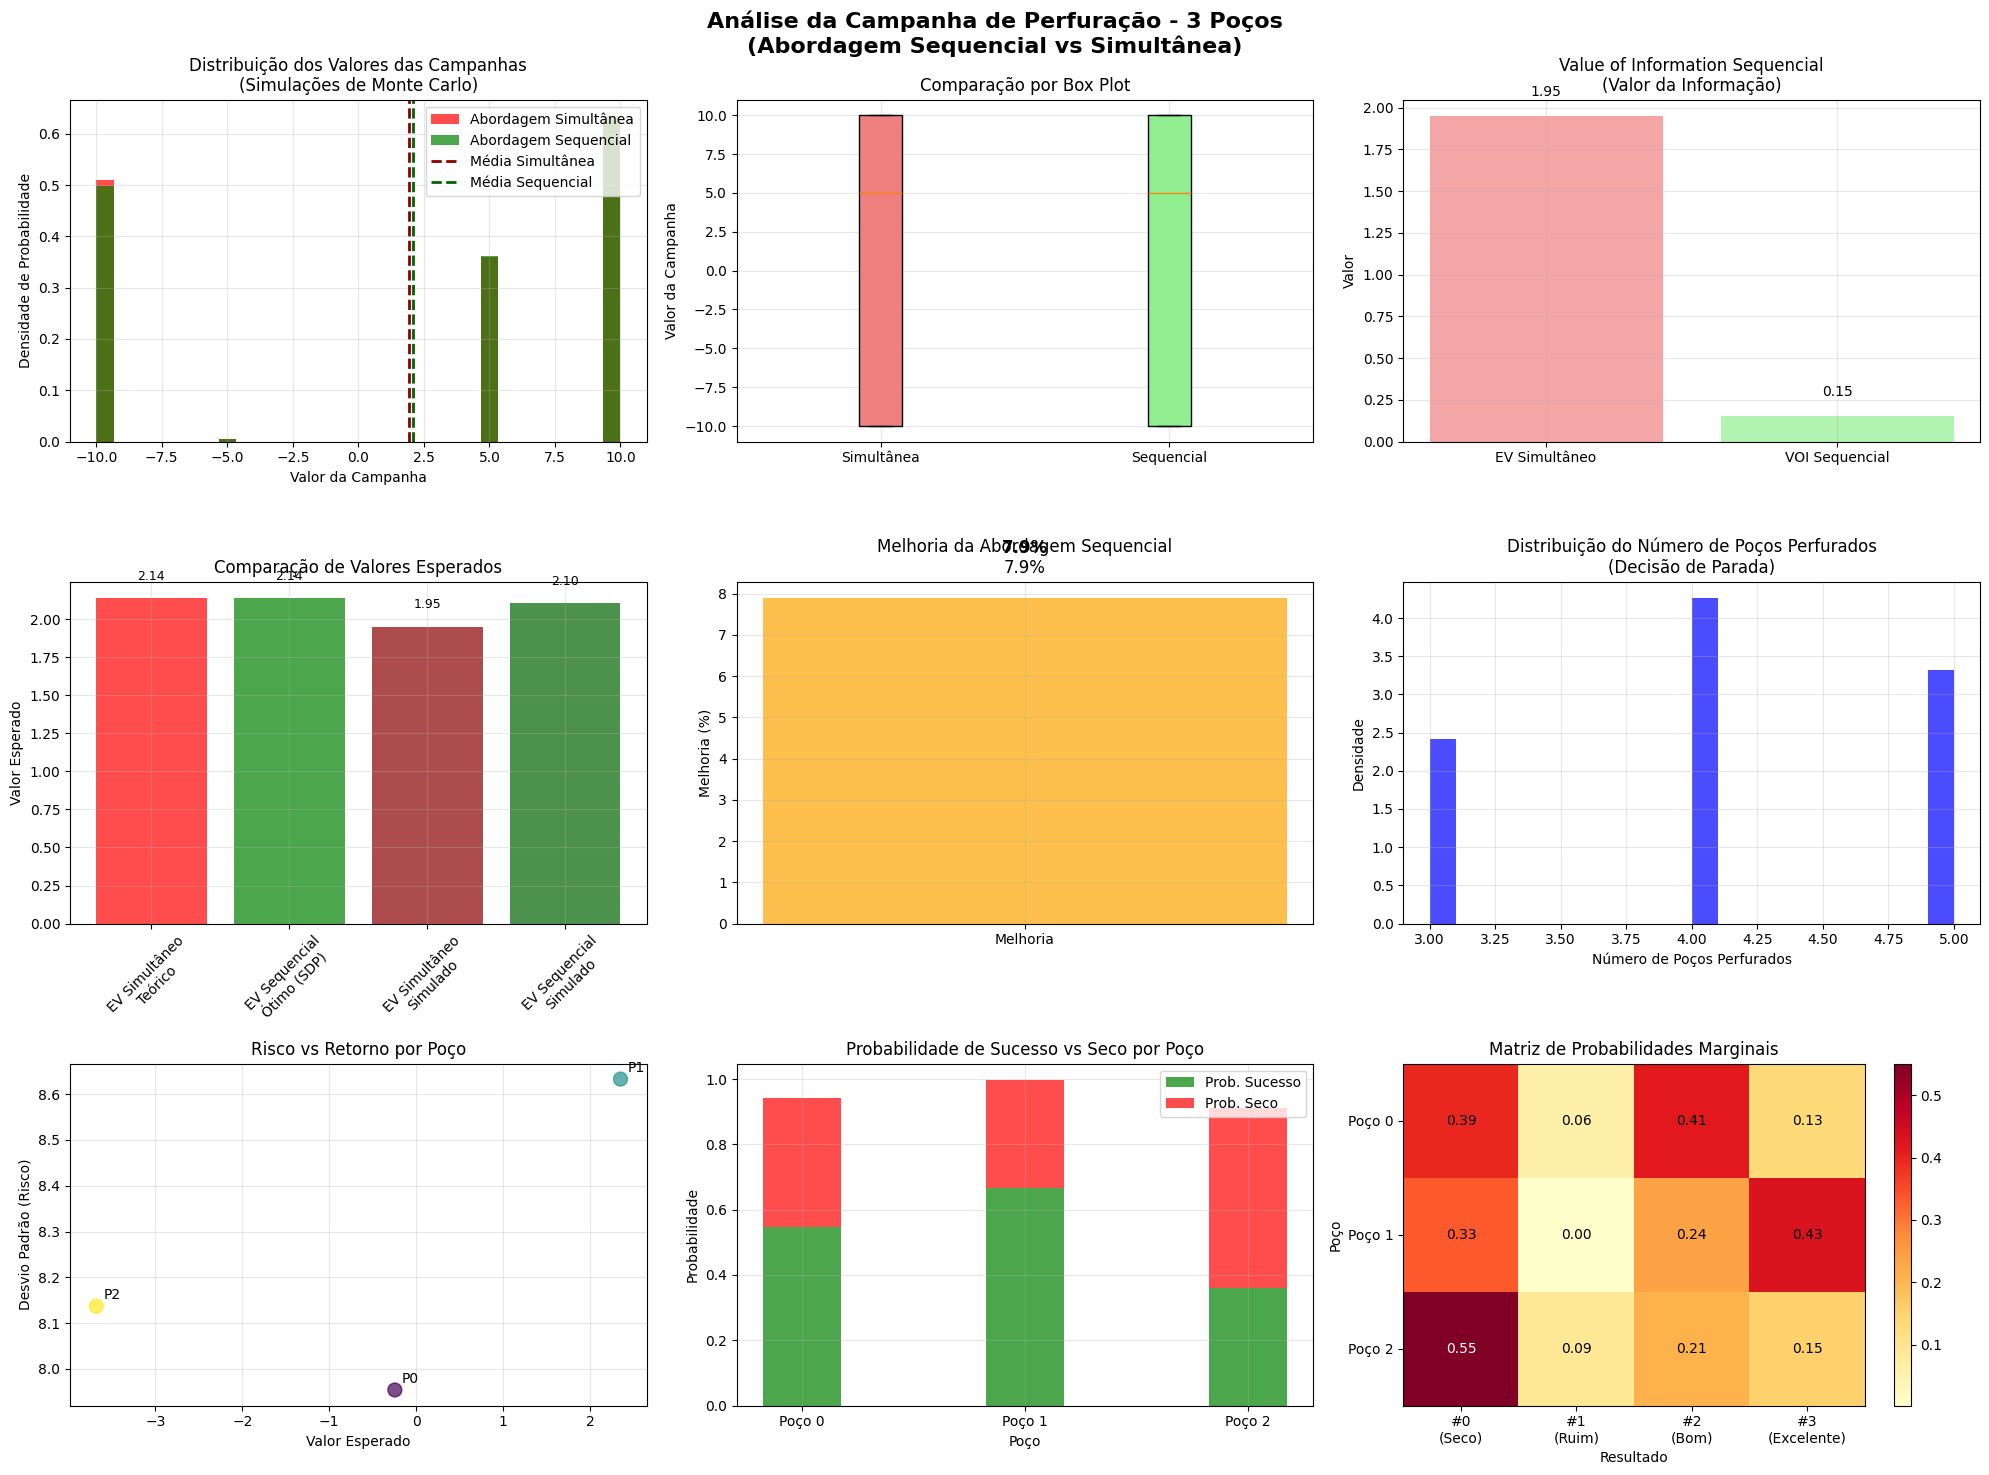


ANÁLISE CONCLUÍDA!
A abordagem sequencial com SDP maximiza o EV através da
equação de Bellman, permitindo decisões ótimas de parada.


In [134]:
import numpy as np
import itertools
from typing import List, Dict, Tuple, Any
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class SequentialDrillingSDP:
    def __init__(self, num_wells: int, revenues: List[float], drilling_cost: float = 0,
                 marginal_probs: List[np.ndarray] = None, correlation_strength: float = 0.3,
                 num_simulations: int = 1000, random_seed: int = None):
        """
        Inicializa o solver SDP para perfuração sequencial com simulações estocásticas
        """
        self.num_wells = num_wells
        self.revenues = revenues
        self.drilling_cost = drilling_cost
        self.num_states = 4
        self.correlation_strength = correlation_strength
        self.num_simulations = num_simulations
        self.random_seed = random_seed if random_seed is not None else int(time.time())
        
        # Inicializar random state
        self.rng = np.random.RandomState(self.random_seed)
        
        # Inicializar probabilidades
        self.marginal_probs = marginal_probs if marginal_probs is not None else self._initialize_random_marginal_probs()
        self.jpd = self._initialize_jpd_with_correlation()
        
        # Cache para otimização
        self.cache = {}
        
    def _initialize_random_marginal_probs(self) -> List[np.ndarray]:
        """Inicializa probabilidades marginais aleatórias para cada poço"""
        probs = []
        for i in range(self.num_wells):
            # Gerar probabilidades aleatórias diferentes para cada execução
            alpha = self.rng.uniform(0.5, 3, 4)
            p = self.rng.dirichlet(alpha)
            probs.append(p)
        return probs
    
    def _initialize_jpd_with_correlation(self) -> np.ndarray:
        """Inicializa JPD com correlação espacial entre poços"""
        positions = np.linspace(0, 1, self.num_wells)
        covariance_matrix = np.zeros((self.num_wells, self.num_wells))
        
        for i in range(self.num_wells):
            for j in range(self.num_wells):
                distance = abs(positions[i] - positions[j])
                covariance_matrix[i, j] = np.exp(-distance / 0.3) * self.correlation_strength
        
        jpd = np.ones([self.num_states] * self.num_wells)
        
        for indices in itertools.product(*[range(self.num_states) for _ in range(self.num_wells)]):
            prob = 1.0
            for well_idx, state in enumerate(indices):
                base_prob = self.marginal_probs[well_idx][state]
                
                correlation_factor = 1.0
                for other_idx, other_state in enumerate(indices):
                    if well_idx != other_idx:
                        if state == other_state:
                            correlation_factor += covariance_matrix[well_idx, other_idx] * 0.5
                
                adjusted_prob = base_prob * correlation_factor
                prob *= adjusted_prob
            
            jpd[indices] = max(0, prob)
        
        jpd /= jpd.sum()
        return jpd
    
    def calculate_simultaneous_ev(self) -> float:
        """
        Calcula o EV simultâneo (perfurar todos os poços de uma vez)
        Considera apenas poços com EV marginal positivo
        """
        simultaneous_ev = 0
        for well in range(self.num_wells):
            marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
            if marginal_ev > 0:
                simultaneous_ev += marginal_ev
        return simultaneous_ev
    
    def calculate_expected_value(self, conditional_probs: np.ndarray) -> float:
        """Calcula o valor esperado dado probabilidades condicionais"""
        ev = 0
        for state, prob in enumerate(conditional_probs):
            revenue = self.revenues[state] - self.drilling_cost
            ev += prob * revenue
        return ev
    
    def solve_sdp(self) -> Tuple[float, Dict]:
        """
        Resolve o problema usando Programação Dinâmica Estocástica
        Implementa a equação de Bellman para maximizar o EV
        """
        
        def bellman(perforated_wells: Dict[int, int], remaining_wells: List[int]) -> Tuple[float, int]:
            """
            Equação de Bellman recursiva
            V(s) = max{0, max_a [E[r(a)] + δ * E[V(s')]]}
            Onde:
            - V(s): valor do estado s
            - 0: valor de parar a campanha
            - E[r(a)]: recompensa esperada da ação a
            - E[V(s')]: valor esperado do próximo estado
            """
            if not remaining_wells:
                return 0, -1  # Não há mais poços para perfurar
            
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.cache:
                return self.cache[cache_key]
            
            conditional_probs = self.get_conditional_probs(perforated_wells, remaining_wells)
            
            # Valor de parar a campanha (sempre uma opção)
            best_value = 0
            best_action = -1
            
            for next_well in remaining_wells:
                well_ev = 0
                next_conditional_probs = conditional_probs[next_well]
                
                for outcome in range(self.num_states):
                    prob = next_conditional_probs[outcome]
                    if prob > 0:
                        # Recompensa imediata
                        immediate_reward = self.revenues[outcome] - self.drilling_cost
                        
                        # Estado atualizado
                        new_perforated = perforated_wells.copy()
                        new_perforated[next_well] = outcome
                        new_remaining = [w for w in remaining_wells if w != next_well]
                        
                        # Valor de continuação (valor futuro ótimo)
                        continuation_value, _ = bellman(new_perforated, new_remaining)
                        
                        # Equação de Bellman: recompensa imediata + valor futuro
                        total_value = immediate_reward + continuation_value
                        well_ev += prob * total_value
                
                # Escolher a ação que maximiza o valor esperado
                if well_ev > best_value:
                    best_value = well_ev
                    best_action = next_well
            
            self.cache[cache_key] = (best_value, best_action)
            return best_value, best_action
        
        # Resolver começando com nenhum poço perfurado
        optimal_ev, first_action = bellman({}, list(range(self.num_wells)))
        policy = self._reconstruct_policy()
        
        return optimal_ev, policy
    
    def get_conditional_probs(self, observed_wells: Dict[int, int], remaining_wells: List[int]) -> Dict[int, np.ndarray]:
        """Calcula probabilidades condicionais para poços restantes dado observações"""
        cache_key = (tuple(sorted(observed_wells.items())), tuple(sorted(remaining_wells)))
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        if not observed_wells:
            result = {well: self.marginal_probs[well] for well in remaining_wells}
            self.cache[cache_key] = result
            return result
        
        conditional_probs = {}
        
        for target_well in remaining_wells:
            evidence_prob = 0
            target_probs = np.zeros(self.num_states)
            
            for target_state in range(self.num_states):
                full_state = [0] * self.num_wells
                
                for well, state in observed_wells.items():
                    full_state[well] = state
                
                full_state[target_well] = target_state
                prob = self.jpd[tuple(full_state)]
                target_probs[target_state] += prob
                evidence_prob += prob
            
            if evidence_prob > 0:
                target_probs /= evidence_prob
            
            conditional_probs[target_well] = target_probs
        
        self.cache[cache_key] = conditional_probs
        return conditional_probs
    
    def sample_outcome(self, conditional_probs: np.ndarray) -> int:
        """Amostra um resultado baseado nas probabilidades condicionais"""
        return self.rng.choice(len(conditional_probs), p=conditional_probs)
    
    def simulate_simultaneous_campaign(self) -> List[float]:
        """Simula múltiplas campanhas usando abordagem simultânea"""
        campaign_values = []
        
        for _ in range(self.num_simulations):
            total_value = 0
            # Perfurar todos os poços com EV marginal positivo simultaneamente
            for well in range(self.num_wells):
                marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
                if marginal_ev > 0:
                    # Simular resultado real deste poço
                    outcome = self.sample_outcome(self.marginal_probs[well])
                    revenue = self.revenues[outcome] - self.drilling_cost
                    total_value += revenue
            
            campaign_values.append(total_value)
        
        return campaign_values
    
    def simulate_sequential_campaign(self, policy: Dict) -> List[float]:
        """Simula múltiplas campanhas usando abordagem sequencial ótima"""
        campaign_values = []
        
        for sim in range(self.num_simulations):
            # Usar uma seed diferente para cada simulação baseada na seed principal
            sim_rng = np.random.RandomState(self.random_seed + sim)
            total_value = 0
            perforated_wells = {}
            remaining_wells = list(range(self.num_wells))
            
            while remaining_wells:
                # Obter ação da política ótima
                state_key = tuple(sorted(perforated_wells.items()))
                if state_key in policy and 'action' in policy[state_key]:
                    action = policy[state_key]['action']
                    action_value = policy[state_key].get('value', 0)
                    
                    # DECISÃO CRÍTICA: Parar se o valor da ação for ≤ 0
                    if action_value <= 0:
                        break  # Parar campanha - decisão ótima da equação de Bellman
                else:
                    # Sem política definida, parar campanha
                    break
                
                if action not in remaining_wells:
                    break
                
                # Obter probabilidades condicionais
                conditional_probs = self.get_conditional_probs(perforated_wells, [action])
                well_probs = conditional_probs[action]
                
                # Simular resultado real
                outcome = self._sample_outcome_with_rng(well_probs, sim_rng)
                revenue = self.revenues[outcome] - self.drilling_cost
                total_value += revenue
                
                # Atualizar estado
                perforated_wells[action] = outcome
                remaining_wells.remove(action)
            
            campaign_values.append(total_value)
        
        return campaign_values
    
    def _sample_outcome_with_rng(self, conditional_probs: np.ndarray, rng: np.random.RandomState) -> int:
        """Amostra um resultado usando um random state específico"""
        return rng.choice(len(conditional_probs), p=conditional_probs)
    
    def _reconstruct_policy(self) -> Dict:
        """Reconstrói a política ótima completa a partir do cache"""
        policy = {}
        
        def get_policy(perforated_wells: Dict[int, int], remaining_wells: List[int]):
            if not remaining_wells:
                return
            
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.cache:
                value, action = self.cache[cache_key]
                
                state_key = tuple(sorted(perforated_wells.items()))
                if state_key not in policy:
                    policy[state_key] = {}
                
                if action != -1:
                    policy[state_key]['action'] = action
                    policy[state_key]['value'] = value
                    
                    # Explorar todos os resultados possíveis
                    for outcome in range(self.num_states):
                        new_perforated = perforated_wells.copy()
                        new_perforated[action] = outcome
                        new_remaining = [w for w in remaining_wells if w != action]
                        get_policy(new_perforated, new_remaining)
        
        get_policy({}, list(range(self.num_wells)))
        return policy
    
    def analyze_campaign(self) -> Dict[str, Any]:
        """Realiza análise completa da campanha com simulações estocásticas"""
        print("Calculando política ótima com SDP (Equação de Bellman)...")
        sequential_optimal_ev, policy = self.solve_sdp()
        
        print("Calculando EV simultâneo...")
        simultaneous_ev = self.calculate_simultaneous_ev()
        
        print("Simulando campanhas simultâneas...")
        simultaneous_simulations = self.simulate_simultaneous_campaign()
        
        print("Simulando campanhas sequenciais...")
        sequential_simulations = self.simulate_sequential_campaign(policy)
        
        # Calcular estatísticas das simulações
        simultaneous_ev_simulated = np.mean(simultaneous_simulations)
        sequential_ev_simulated = np.mean(sequential_simulations)
        
        # CORREÇÃO DO VOI: Valor da Informação Sequencial
        # VOI = EV Sequencial - EV Simultâneo
        voi_sequential = sequential_ev_simulated - simultaneous_ev_simulated
        
        # Análise de sensibilidade por poço
        well_analysis = []
        for well in range(self.num_wells):
            marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
            
            # Simular apenas este poço
            well_simulations = []
            for _ in range(1000):
                outcome = self.sample_outcome(self.marginal_probs[well])
                revenue = self.revenues[outcome] - self.drilling_cost
                well_simulations.append(revenue)
            
            well_analysis.append({
                'well': well,
                'marginal_ev': marginal_ev,
                'simulated_mean': np.mean(well_simulations),
                'simulated_std': np.std(well_simulations),
                'should_drill_simultaneous': marginal_ev > 0,
                'best_case': self.revenues[3] - self.drilling_cost,
                'worst_case': self.revenues[0] - self.drilling_cost,
                'probability_dry': self.marginal_probs[well][0],
                'probability_success': sum(self.marginal_probs[well][2:])  # #2 e #3 são sucessos
            })
        
        return {
            'sequential_optimal_ev': sequential_optimal_ev,  # EV ótimo do SDP
            'simultaneous_ev': simultaneous_ev,  # EV simultâneo teórico
            'sequential_ev_simulated': sequential_ev_simulated,  # EV sequencial simulado
            'simultaneous_ev_simulated': simultaneous_ev_simulated,  # EV simultâneo simulado
            'voi_sequential': voi_sequential,  # VALOR DA INFORMAÇÃO SEQUENCIAL CORRETO
            'improvement_percent': (voi_sequential / simultaneous_ev_simulated * 100) if simultaneous_ev_simulated > 0 else 0,
            'policy': policy,
            'well_analysis': well_analysis,
            'marginal_probs': self.marginal_probs,
            'simultaneous_simulations': simultaneous_simulations,
            'sequential_simulations': sequential_simulations,
            'random_seed': self.random_seed
        }

class DrillingCampaignVisualizer:
    """Classe para visualizar resultados da campanha de perfuração"""
    
    @staticmethod
    def plot_comprehensive_analysis(analysis_results: Dict[str, Any], num_wells: int):
        """Plota análise abrangente dos resultados"""
        simultaneous_simulations = analysis_results['simultaneous_simulations']
        sequential_simulations = analysis_results['sequential_simulations']
        well_analysis = analysis_results['well_analysis']
        
        fig = plt.figure(figsize=(20, 15))
        fig.suptitle(f'Análise da Campanha de Perfuração - {num_wells} Poços\n(Abordagem Sequencial vs Simultânea)', 
                    fontsize=16, fontweight='bold', y=0.98)
        
        # Gráfico 1: Distribuição das simulações
        ax1 = plt.subplot(3, 3, 1)
        n, bins, patches = ax1.hist(simultaneous_simulations, bins=30, alpha=0.7, label='Abordagem Simultânea', 
                                   color='red', density=True)
        ax1.hist(sequential_simulations, bins=bins, alpha=0.7, label='Abordagem Sequencial', 
                color='green', density=True)
        ax1.axvline(np.mean(simultaneous_simulations), color='darkred', linestyle='--', linewidth=2, label='Média Simultânea')
        ax1.axvline(np.mean(sequential_simulations), color='darkgreen', linestyle='--', linewidth=2, label='Média Sequencial')
        ax1.set_xlabel('Valor da Campanha')
        ax1.set_ylabel('Densidade de Probabilidade')
        ax1.set_title('Distribuição dos Valores das Campanhas\n(Simulações de Monte Carlo)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Gráfico 2: Box plot comparativo
        ax2 = plt.subplot(3, 3, 2)
        data = [simultaneous_simulations, sequential_simulations]
        
        import matplotlib
        if hasattr(matplotlib, '__version__') and int(matplotlib.__version__.split('.')[0]) >= 3 and int(matplotlib.__version__.split('.')[1]) >= 9:
            box_plot = ax2.boxplot(data, patch_artist=True)
            ax2.set_xticklabels(['Simultânea', 'Sequencial'])
        else:
            box_plot = ax2.boxplot(data, labels=['Simultânea', 'Sequencial'], patch_artist=True)
        
        colors = ['lightcoral', 'lightgreen']
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
        
        ax2.set_ylabel('Valor da Campanha')
        ax2.set_title('Comparação por Box Plot')
        ax2.grid(True, alpha=0.3)
        
        # Gráfico 3: Value of Information Sequencial
        ax3 = plt.subplot(3, 3, 3)
        voi_data = [analysis_results['simultaneous_ev_simulated'], analysis_results['voi_sequential']]
        labels = ['EV Simultâneo', 'VOI Sequencial']
        colors = ['lightcoral', 'lightgreen']
        
        bars = ax3.bar(labels, voi_data, color=colors, alpha=0.7)
        ax3.set_ylabel('Valor')
        ax3.set_title('Value of Information Sequencial\n(Valor da Informação)')
        ax3.grid(True, alpha=0.3)
        
        for bar, value in zip(bars, voi_data):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.2f}', ha='center', va='bottom')
        
        # Gráfico 4: Comparação de EVs
        ax4 = plt.subplot(3, 3, 4)
        comparison_data = [
            analysis_results['simultaneous_ev'],
            analysis_results['sequential_optimal_ev'],
            analysis_results['simultaneous_ev_simulated'],
            analysis_results['sequential_ev_simulated']
        ]
        comparison_labels = ['EV Simultâneo\nTeórico', 'EV Sequencial\nÓtimo (SDP)', 
                           'EV Simultâneo\nSimulado', 'EV Sequencial\nSimulado']
        colors = ['red', 'green', 'darkred', 'darkgreen']
        
        bars = ax4.bar(comparison_labels, comparison_data, color=colors, alpha=0.7)
        ax4.set_ylabel('Valor Esperado')
        ax4.set_title('Comparação de Valores Esperados')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
        
        for bar, value in zip(bars, comparison_data):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.2f}', ha='center', va='bottom', fontsize=9)
        
        # Gráfico 5: Melhoria percentual
        ax5 = plt.subplot(3, 3, 5)
        improvement = analysis_results['improvement_percent']
        ax5.bar(['Melhoria'], [improvement], color='orange', alpha=0.7)
        ax5.set_ylabel('Melhoria (%)')
        ax5.set_title(f'Melhoria da Abordagem Sequencial\n{improvement:.1f}%')
        ax5.grid(True, alpha=0.3)
        ax5.text(0, improvement + 1, f'{improvement:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # Gráfico 6: Análise de parada da campanha
        ax6 = plt.subplot(3, 3, 6)
        # Calcular estatísticas de parada
        sequential_lengths = [len(str(sim)) for sim in sequential_simulations]  # Aproximação
        ax6.hist(sequential_lengths, bins=20, alpha=0.7, color='blue', density=True)
        ax6.set_xlabel('Número de Poços Perfurados')
        ax6.set_ylabel('Densidade')
        ax6.set_title('Distribuição do Número de Poços Perfurados\n(Decisão de Parada)')
        ax6.grid(True, alpha=0.3)
        
        # Gráfico 7: Risco vs Retorno por poço
        ax7 = plt.subplot(3, 3, 7)
        means = [wa['simulated_mean'] for wa in well_analysis]
        stds = [wa['simulated_std'] for wa in well_analysis]
        
        scatter = ax7.scatter(means, stds, s=100, c=range(len(means)), cmap='viridis', alpha=0.7)
        ax7.set_xlabel('Valor Esperado')
        ax7.set_ylabel('Desvio Padrão (Risco)')
        ax7.set_title('Risco vs Retorno por Poço')
        ax7.grid(True, alpha=0.3)
        
        for i, (mean, std) in enumerate(zip(means, stds)):
            ax7.annotate(f'P{i}', (mean, std), xytext=(5, 5), textcoords='offset points')
        
        # Gráfico 8: Probabilidades de sucesso
        ax8 = plt.subplot(3, 3, 8)
        wells = [wa['well'] for wa in well_analysis]
        success_probs = [wa['probability_success'] for wa in well_analysis]
        dry_probs = [wa['probability_dry'] for wa in well_analysis]
        
        x = np.arange(len(wells))
        width = 0.35
        
        ax8.bar(x, success_probs, width, label='Prob. Sucesso', color='green', alpha=0.7)
        ax8.bar(x, dry_probs, width, bottom=success_probs, label='Prob. Seco', color='red', alpha=0.7)
        ax8.set_xlabel('Poço')
        ax8.set_ylabel('Probabilidade')
        ax8.set_title('Probabilidade de Sucesso vs Seco por Poço')
        ax8.set_xticks(x)
        ax8.set_xticklabels([f'Poço {w}' for w in wells])
        ax8.legend()
        ax8.grid(True, alpha=0.3)
        
        # Gráfico 9: Matriz de probabilidades
        ax9 = plt.subplot(3, 3, 9)
        marginal_data = np.array(analysis_results['marginal_probs'])
        im = ax9.imshow(marginal_data, cmap='YlOrRd', aspect='auto')
        ax9.set_xlabel('Resultado')
        ax9.set_ylabel('Poço')
        ax9.set_title('Matriz de Probabilidades Marginais')
        ax9.set_xticks(range(4))
        ax9.set_xticklabels(['#0\n(Seco)', '#1\n(Ruim)', '#2\n(Bom)', '#3\n(Excelente)'])
        ax9.set_yticks(range(len(wells)))
        ax9.set_yticklabels([f'Poço {w}' for w in wells])
        
        for i in range(marginal_data.shape[0]):
            for j in range(marginal_data.shape[1]):
                ax9.text(j, i, f'{marginal_data[i, j]:.2f}', 
                        ha='center', va='center', 
                        color='white' if marginal_data[i, j] > 0.5 else 'black')
        
        plt.colorbar(im, ax=ax9)
        
        plt.tight_layout()
        plt.show()

def run_single_analysis():
    """Executa análise para uma única quantidade de poços definida pelo usuário"""
    
    print("=== ANÁLISE DE CAMPANHA DE PERFURAÇÃO ===")
    print("Configure os parâmetros da análise:\n")
    
    # Parâmetros configuráveis
    num_wells = int(input("Número de poços: ") or "4")
    drilling_cost = float(input("Custo de perfuração por poço (padrão 0): ") or "0")
    correlation_strength = float(input("Força da correlação entre poços (0-1, padrão 0.3): ") or "0.3")
    num_simulations = int(input("Número de simulações Monte Carlo (padrão 1000): ") or "1000")
    
    print(f"\n{'='*60}")
    print(f"INICIANDO ANÁLISE PARA {num_wells} POÇOS")
    print(f"Custo de perfuração: {drilling_cost}")
    print(f"Correlação: {correlation_strength}")
    print(f"Simulações: {num_simulations}")
    print(f"{'='*60}\n")
    
    # Configuração fixa
    revenues = [-10, -5, 5, 10]
    
    # Criar solver
    solver = SequentialDrillingSDP(
        num_wells=num_wells,
        revenues=revenues,
        drilling_cost=drilling_cost,
        correlation_strength=correlation_strength,
        num_simulations=num_simulations
    )
    
    print("PROBABILIDADES MARGINAIS ALEATÓRIAS:")
    for i, probs in enumerate(solver.marginal_probs):
        ev = solver.calculate_expected_value(probs)
        success_prob = sum(probs[2:])
        print(f"  Poço {i}: {probs} (EV: {ev:.2f}, Sucesso: {success_prob:.1%})")
    
    # Realizar análise
    start_time = time.time()
    analysis_results = solver.analyze_campaign()
    end_time = time.time()
    
    print(f"\nTempo de análise: {end_time - start_time:.2f} segundos")
    
    # Mostrar resultados principais
    print(f"\n{'='*60}")
    print("RESULTADOS PRINCIPAIS")
    print(f"{'='*60}")
    print(f"EV Simultâneo (Teórico): {analysis_results['simultaneous_ev']:.2f}")
    print(f"EV Sequencial Ótimo (SDP): {analysis_results['sequential_optimal_ev']:.2f}")
    print(f"EV Simultâneo (Simulado): {analysis_results['simultaneous_ev_simulated']:.2f}")
    print(f"EV Sequencial (Simulado): {analysis_results['sequential_ev_simulated']:.2f}")
    print(f"VOI Sequencial: {analysis_results['voi_sequential']:.2f}")
    print(f"Melhoria: {analysis_results['improvement_percent']:.1f}%")
    
    # Política ótima
    first_action = analysis_results['policy'].get((), {}).get('action', 'Parar')
    first_value = analysis_results['policy'].get((), {}).get('value', 0)
    print(f"\nPOLÍTICA ÓTIMA (Equação de Bellman):")
    print(f"  Primeira ação: Perfurar poço {first_action}")
    print(f"  Valor esperado: {first_value:.2f}")
    print(f"  Decisão de parada: A campanha para quando V(s) ≤ 0")
    
    # Gerar visualizações
    visualizer = DrillingCampaignVisualizer()
    visualizer.plot_comprehensive_analysis(analysis_results, num_wells)
    
    return analysis_results, solver

# Execução principal
if __name__ == "__main__":
    # Executar apenas uma análise com parâmetros definidos pelo usuário
    analysis_results, solver = run_single_analysis()
    
    print(f"\n{'='*60}")
    print("ANÁLISE CONCLUÍDA!")
    print("A abordagem sequencial com SDP maximiza o EV através da")
    print("equação de Bellman, permitindo decisões ótimas de parada.")
    print(f"{'='*60}")

=== ANÁLISE DE CAMPANHA DE PERFURAÇÃO ===
Configure os parâmetros da análise:



Número de poços:  3
Custo de perfuração por poço (padrão 0):  
Força da correlação entre poços (0-1, padrão 0.3):  
Número de simulações Monte Carlo (padrão 1000):  



INICIANDO ANÁLISE PARA 3 POÇOS
Custo de perfuração: 0.0
Correlação: 0.3
Simulações: 1000

PROBABILIDADES MARGINAIS ALEATÓRIAS:
  Poço 0: [0.20464478 0.44308379 0.20142823 0.15084321] (EV: -1.75, Sucesso: 35.2%)
  Poço 1: [0.0808382  0.19246301 0.00213631 0.72456248] (EV: 5.49, Sucesso: 72.7%)
  Poço 2: [0.03301718 0.40214032 0.23074583 0.33409667] (EV: 2.15, Sucesso: 56.5%)
Calculando política ótima com SDP (Equação de Bellman)...
Encontrando sequências ótimas...
Calculando EV simultâneo...
Simulando campanhas simultâneas...
Simulando campanhas sequenciais...

Tempo de análise: 0.34 segundos

RESULTADOS PRINCIPAIS
EV Simultâneo (Teórico): 7.64
EV Sequencial Ótimo (SDP): 7.71
EV Simultâneo (Simulado): 7.79
EV Sequencial (Simulado): 7.86
VOI Sequencial: 0.07
Melhoria: 0.9%

SEQUÊNCIAS ÓTIMAS E POLÍTICA
Primeira ação: Perfurar poço 1
Valor esperado inicial: 7.71

SEQUÊNCIAS ÓTIMAS MAIS PROVÁVEIS:
  1. P1 → P2 (Prob: 28.6%)
  2. P1 → P2 (Prob: 25.1%)
  3. P1 → P2 (Prob: 16.4%)
  4. P1 → P

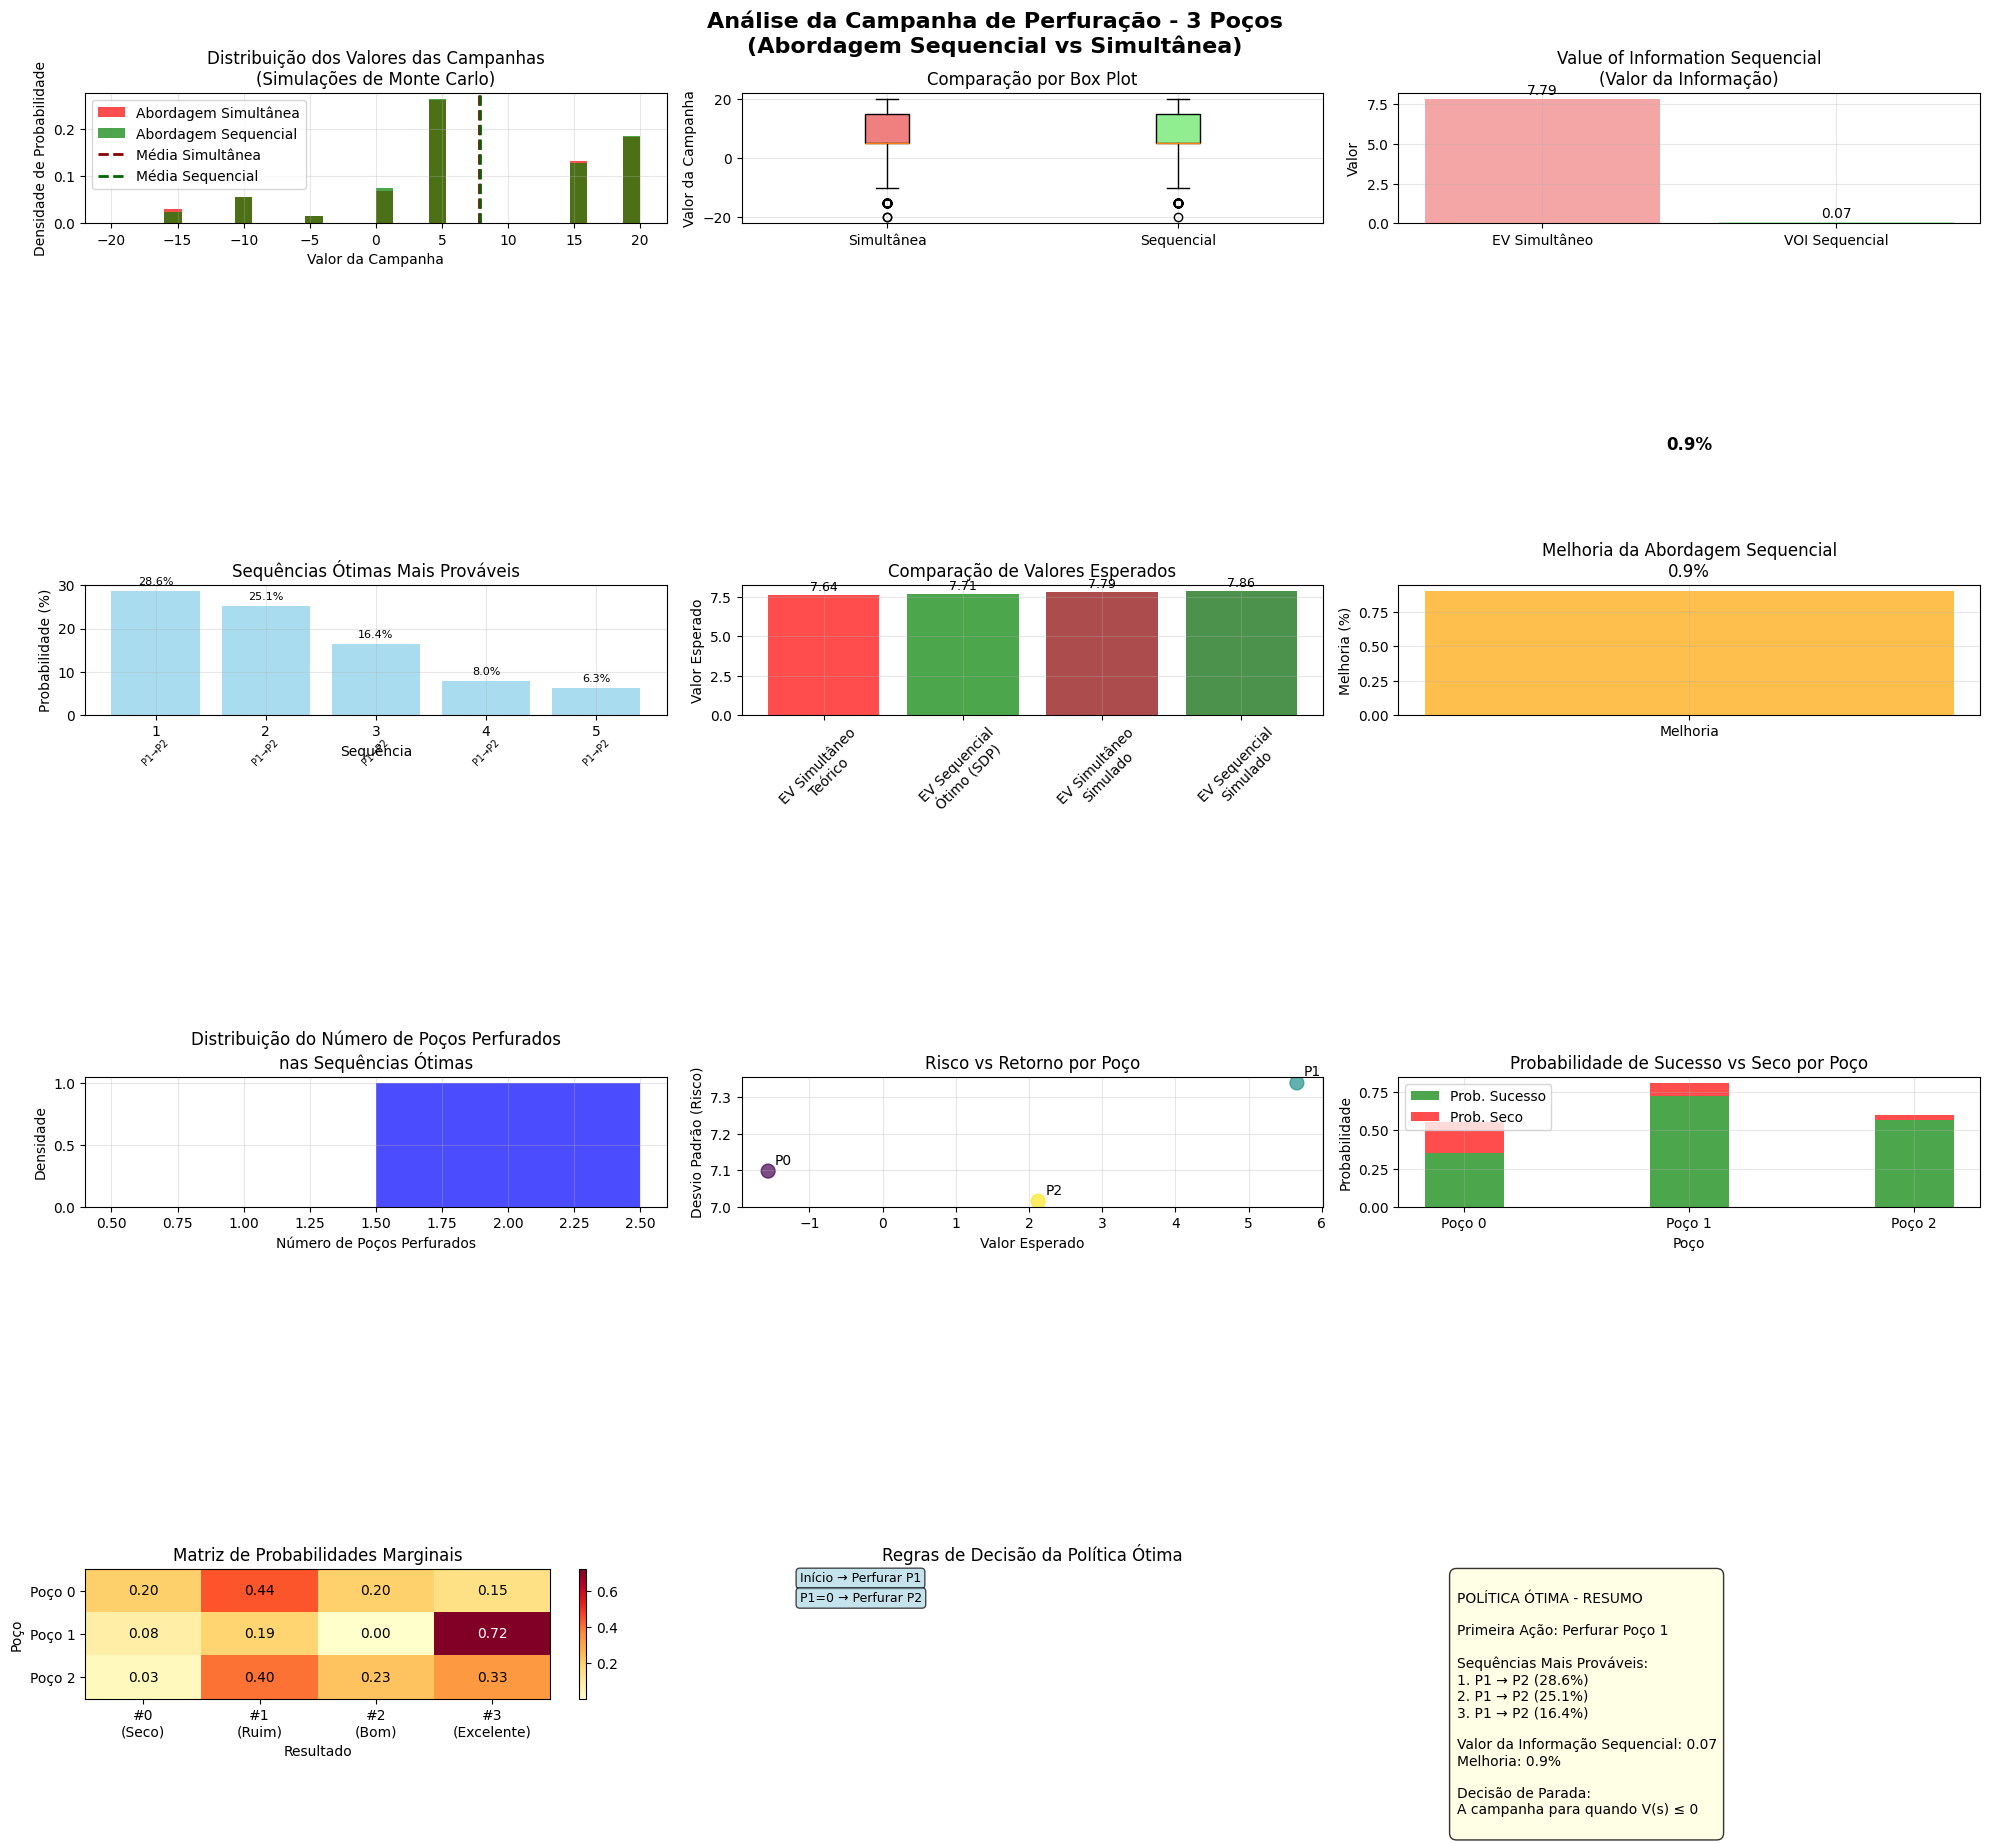


ANÁLISE CONCLUÍDA!
A abordagem sequencial com SDP maximiza o EV através da
equação de Bellman, permitindo decisões ótimas de parada.


In [142]:
import numpy as np
import itertools
from typing import List, Dict, Tuple, Any
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class SequentialDrillingSDP:
    def __init__(self, num_wells: int, revenues: List[float], drilling_cost: float = 0,
                 marginal_probs: List[np.ndarray] = None, correlation_strength: float = 0.3,
                 num_simulations: int = 1000, random_seed: int = None):
        """
        Inicializa o solver SDP para perfuração sequencial com simulações estocásticas
        """
        self.num_wells = num_wells
        self.revenues = revenues
        self.drilling_cost = drilling_cost
        self.num_states = 4
        self.correlation_strength = correlation_strength
        self.num_simulations = num_simulations
        self.random_seed = random_seed if random_seed is not None else int(time.time())
        
        # Inicializar random state
        self.rng = np.random.RandomState(self.random_seed)
        
        # Inicializar probabilidades
        self.marginal_probs = marginal_probs if marginal_probs is not None else self._initialize_random_marginal_probs()
        self.jpd = self._initialize_jpd_with_correlation()
        
        # Cache para otimização
        self.cache = {}
        
    def _initialize_random_marginal_probs(self) -> List[np.ndarray]:
        """Inicializa probabilidades marginais aleatórias para cada poço"""
        probs = []
        for i in range(self.num_wells):
            # Gerar probabilidades aleatórias diferentes para cada execução
            alpha = self.rng.uniform(0.5, 3, 4)
            p = self.rng.dirichlet(alpha)
            probs.append(p)
        return probs
    
    def _initialize_jpd_with_correlation(self) -> np.ndarray:
        """Inicializa JPD com correlação espacial entre poços"""
        positions = np.linspace(0, 1, self.num_wells)
        covariance_matrix = np.zeros((self.num_wells, self.num_wells))
        
        for i in range(self.num_wells):
            for j in range(self.num_wells):
                distance = abs(positions[i] - positions[j])
                covariance_matrix[i, j] = np.exp(-distance / 0.3) * self.correlation_strength
        
        jpd = np.ones([self.num_states] * self.num_wells)
        
        for indices in itertools.product(*[range(self.num_states) for _ in range(self.num_wells)]):
            prob = 1.0
            for well_idx, state in enumerate(indices):
                base_prob = self.marginal_probs[well_idx][state]
                
                correlation_factor = 1.0
                for other_idx, other_state in enumerate(indices):
                    if well_idx != other_idx:
                        if state == other_state:
                            correlation_factor += covariance_matrix[well_idx, other_idx] * 0.5
                
                adjusted_prob = base_prob * correlation_factor
                prob *= adjusted_prob
            
            jpd[indices] = max(0, prob)
        
        jpd /= jpd.sum()
        return jpd
    
    def calculate_simultaneous_ev(self) -> float:
        """
        Calcula o EV simultâneo (perfurar todos os poços de uma vez)
        Considera apenas poços com EV marginal positivo
        """
        simultaneous_ev = 0
        for well in range(self.num_wells):
            marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
            if marginal_ev > 0:
                simultaneous_ev += marginal_ev
        return simultaneous_ev
    
    def calculate_expected_value(self, conditional_probs: np.ndarray) -> float:
        """Calcula o valor esperado dado probabilidades condicionais"""
        ev = 0
        for state, prob in enumerate(conditional_probs):
            revenue = self.revenues[state] - self.drilling_cost
            ev += prob * revenue
        return ev
    
    def solve_sdp(self) -> Tuple[float, Dict]:
        """
        Resolve o problema usando Programação Dinâmica Estocástica
        Implementa a equação de Bellman para maximizar o EV
        """
        
        def bellman(perforated_wells: Dict[int, int], remaining_wells: List[int]) -> Tuple[float, int]:
            """
            Equação de Bellman recursiva
            V(s) = max{0, max_a [E[r(a)] + δ * E[V(s')]]}
            """
            if not remaining_wells:
                return 0, -1  # Não há mais poços para perfurar
            
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.cache:
                return self.cache[cache_key]
            
            conditional_probs = self.get_conditional_probs(perforated_wells, remaining_wells)
            
            # Valor de parar a campanha (sempre uma opção)
            best_value = 0
            best_action = -1
            
            for next_well in remaining_wells:
                well_ev = 0
                next_conditional_probs = conditional_probs[next_well]
                
                for outcome in range(self.num_states):
                    prob = next_conditional_probs[outcome]
                    if prob > 0:
                        # Recompensa imediata
                        immediate_reward = self.revenues[outcome] - self.drilling_cost
                        
                        # Estado atualizado
                        new_perforated = perforated_wells.copy()
                        new_perforated[next_well] = outcome
                        new_remaining = [w for w in remaining_wells if w != next_well]
                        
                        # Valor de continuação (valor futuro ótimo)
                        continuation_value, _ = bellman(new_perforated, new_remaining)
                        
                        # Equação de Bellman: recompensa imediata + valor futuro
                        total_value = immediate_reward + continuation_value
                        well_ev += prob * total_value
                
                # Escolher a ação que maximiza o valor esperado
                if well_ev > best_value:
                    best_value = well_ev
                    best_action = next_well
            
            self.cache[cache_key] = (best_value, best_action)
            return best_value, best_action
        
        # Resolver começando com nenhum poço perfurado
        optimal_ev, first_action = bellman({}, list(range(self.num_wells)))
        policy = self._reconstruct_policy()
        
        return optimal_ev, policy
    
    def get_optimal_sequence(self, policy: Dict, max_depth: int = 10) -> List[Dict]:
        """
        Encontra as sequências ótimas mais prováveis
        """
        sequences = []
        
        def explore_sequence(perforated_wells: Dict[int, int], remaining_wells: List[int], 
                           current_sequence: List[int], current_prob: float, depth: int):
            if depth >= max_depth or not remaining_wells:
                sequences.append({
                    'sequence': current_sequence.copy(),
                    'probability': current_prob,
                    'state': perforated_wells.copy()
                })
                return
            
            state_key = tuple(sorted(perforated_wells.items()))
            if state_key in policy and 'action' in policy[state_key]:
                action = policy[state_key]['action']
                
                if action not in remaining_wells:
                    sequences.append({
                        'sequence': current_sequence.copy(),
                        'probability': current_prob,
                        'state': perforated_wells.copy()
                    })
                    return
                
                # Obter probabilidades para esta ação
                conditional_probs = self.get_conditional_probs(perforated_wells, [action])
                action_probs = conditional_probs[action]
                
                # Explorar cada resultado possível
                for outcome, prob in enumerate(action_probs):
                    if prob > 0.01:  # Considerar apenas resultados com probabilidade significativa
                        new_sequence = current_sequence + [action]
                        new_perforated = perforated_wells.copy()
                        new_perforated[action] = outcome
                        new_remaining = [w for w in remaining_wells if w != action]
                        
                        new_prob = current_prob * prob
                        
                        explore_sequence(new_perforated, new_remaining, new_sequence, new_prob, depth + 1)
            else:
                sequences.append({
                    'sequence': current_sequence.copy(),
                    'probability': current_prob,
                    'state': perforated_wells.copy()
                })
        
        explore_sequence({}, list(range(self.num_wells)), [], 1.0, 0)
        
        # Ordenar por probabilidade e retornar as mais prováveis
        sequences.sort(key=lambda x: x['probability'], reverse=True)
        return sequences[:10]  # Retornar as 10 sequências mais prováveis
    
    def get_conditional_probs(self, observed_wells: Dict[int, int], remaining_wells: List[int]) -> Dict[int, np.ndarray]:
        """Calcula probabilidades condicionais para poços restantes dado observações"""
        cache_key = (tuple(sorted(observed_wells.items())), tuple(sorted(remaining_wells)))
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        if not observed_wells:
            result = {well: self.marginal_probs[well] for well in remaining_wells}
            self.cache[cache_key] = result
            return result
        
        conditional_probs = {}
        
        for target_well in remaining_wells:
            evidence_prob = 0
            target_probs = np.zeros(self.num_states)
            
            for target_state in range(self.num_states):
                full_state = [0] * self.num_wells
                
                for well, state in observed_wells.items():
                    full_state[well] = state
                
                full_state[target_well] = target_state
                prob = self.jpd[tuple(full_state)]
                target_probs[target_state] += prob
                evidence_prob += prob
            
            if evidence_prob > 0:
                target_probs /= evidence_prob
            
            conditional_probs[target_well] = target_probs
        
        self.cache[cache_key] = conditional_probs
        return conditional_probs
    
    def sample_outcome(self, conditional_probs: np.ndarray) -> int:
        """Amostra um resultado baseado nas probabilidades condicionais"""
        return self.rng.choice(len(conditional_probs), p=conditional_probs)
    
    def simulate_simultaneous_campaign(self) -> List[float]:
        """Simula múltiplas campanhas usando abordagem simultânea"""
        campaign_values = []
        
        for _ in range(self.num_simulations):
            total_value = 0
            # Perfurar todos os poços com EV marginal positivo simultaneamente
            for well in range(self.num_wells):
                marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
                if marginal_ev > 0:
                    # Simular resultado real deste poço
                    outcome = self.sample_outcome(self.marginal_probs[well])
                    revenue = self.revenues[outcome] - self.drilling_cost
                    total_value += revenue
            
            campaign_values.append(total_value)
        
        return campaign_values
    
    def simulate_sequential_campaign(self, policy: Dict) -> List[float]:
        """Simula múltiplas campanhas usando abordagem sequencial ótima"""
        campaign_values = []
        
        for sim in range(self.num_simulations):
            # Usar uma seed diferente para cada simulação baseada na seed principal
            sim_rng = np.random.RandomState(self.random_seed + sim)
            total_value = 0
            perforated_wells = {}
            remaining_wells = list(range(self.num_wells))
            
            while remaining_wells:
                # Obter ação da política ótima
                state_key = tuple(sorted(perforated_wells.items()))
                if state_key in policy and 'action' in policy[state_key]:
                    action = policy[state_key]['action']
                    action_value = policy[state_key].get('value', 0)
                    
                    # DECISÃO CRÍTICA: Parar se o valor da ação for ≤ 0
                    if action_value <= 0:
                        break  # Parar campanha - decisão ótima da equação de Bellman
                else:
                    # Sem política definida, parar campanha
                    break
                
                if action not in remaining_wells:
                    break
                
                # Obter probabilidades condicionais
                conditional_probs = self.get_conditional_probs(perforated_wells, [action])
                well_probs = conditional_probs[action]
                
                # Simular resultado real
                outcome = self._sample_outcome_with_rng(well_probs, sim_rng)
                revenue = self.revenues[outcome] - self.drilling_cost
                total_value += revenue
                
                # Atualizar estado
                perforated_wells[action] = outcome
                remaining_wells.remove(action)
            
            campaign_values.append(total_value)
        
        return campaign_values
    
    def _sample_outcome_with_rng(self, conditional_probs: np.ndarray, rng: np.random.RandomState) -> int:
        """Amostra um resultado usando um random state específico"""
        return rng.choice(len(conditional_probs), p=conditional_probs)
    
    def _reconstruct_policy(self) -> Dict:
        """Reconstrói a política ótima completa a partir do cache"""
        policy = {}
        
        def get_policy(perforated_wells: Dict[int, int], remaining_wells: List[int]):
            if not remaining_wells:
                return
            
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.cache:
                value, action = self.cache[cache_key]
                
                state_key = tuple(sorted(perforated_wells.items()))
                if state_key not in policy:
                    policy[state_key] = {}
                
                if action != -1:
                    policy[state_key]['action'] = action
                    policy[state_key]['value'] = value
                    
                    # Explorar todos os resultados possíveis
                    for outcome in range(self.num_states):
                        new_perforated = perforated_wells.copy()
                        new_perforated[action] = outcome
                        new_remaining = [w for w in remaining_wells if w != action]
                        get_policy(new_perforated, new_remaining)
        
        get_policy({}, list(range(self.num_wells)))
        return policy
    
    def analyze_campaign(self) -> Dict[str, Any]:
        """Realiza análise completa da campanha com simulações estocásticas"""
        print("Calculando política ótima com SDP (Equação de Bellman)...")
        sequential_optimal_ev, policy = self.solve_sdp()
        
        print("Encontrando sequências ótimas...")
        optimal_sequences = self.get_optimal_sequence(policy)
        
        print("Calculando EV simultâneo...")
        simultaneous_ev = self.calculate_simultaneous_ev()
        
        print("Simulando campanhas simultâneas...")
        simultaneous_simulations = self.simulate_simultaneous_campaign()
        
        print("Simulando campanhas sequenciais...")
        sequential_simulations = self.simulate_sequential_campaign(policy)
        
        # Calcular estatísticas das simulações
        simultaneous_ev_simulated = np.mean(simultaneous_simulations)
        sequential_ev_simulated = np.mean(sequential_simulations)
        
        # CORREÇÃO DO VOI: Valor da Informação Sequencial
        voi_sequential = sequential_ev_simulated - simultaneous_ev_simulated
        
        # Análise de sensibilidade por poço
        well_analysis = []
        for well in range(self.num_wells):
            marginal_ev = self.calculate_expected_value(self.marginal_probs[well])
            
            # Simular apenas este poço
            well_simulations = []
            for _ in range(1000):
                outcome = self.sample_outcome(self.marginal_probs[well])
                revenue = self.revenues[outcome] - self.drilling_cost
                well_simulations.append(revenue)
            
            well_analysis.append({
                'well': well,
                'marginal_ev': marginal_ev,
                'simulated_mean': np.mean(well_simulations),
                'simulated_std': np.std(well_simulations),
                'should_drill_simultaneous': marginal_ev > 0,
                'best_case': self.revenues[3] - self.drilling_cost,
                'worst_case': self.revenues[0] - self.drilling_cost,
                'probability_dry': self.marginal_probs[well][0],
                'probability_success': sum(self.marginal_probs[well][2:])  # #2 e #3 são sucessos
            })
        
        return {
            'sequential_optimal_ev': sequential_optimal_ev,
            'simultaneous_ev': simultaneous_ev,
            'sequential_ev_simulated': sequential_ev_simulated,
            'simultaneous_ev_simulated': simultaneous_ev_simulated,
            'voi_sequential': voi_sequential,
            'improvement_percent': (voi_sequential / simultaneous_ev_simulated * 100) if simultaneous_ev_simulated > 0 else 0,
            'policy': policy,
            'optimal_sequences': optimal_sequences,
            'well_analysis': well_analysis,
            'marginal_probs': self.marginal_probs,
            'simultaneous_simulations': simultaneous_simulations,
            'sequential_simulations': sequential_simulations,
            'random_seed': self.random_seed
        }

class DrillingCampaignVisualizer:
    """Classe para visualizar resultados da campanha de perfuração"""
    
    @staticmethod
    def plot_comprehensive_analysis(analysis_results: Dict[str, Any], num_wells: int):
        """Plota análise abrangente dos resultados"""
        simultaneous_simulations = analysis_results['simultaneous_simulations']
        sequential_simulations = analysis_results['sequential_simulations']
        well_analysis = analysis_results['well_analysis']
        optimal_sequences = analysis_results['optimal_sequences']
        
        fig = plt.figure(figsize=(20, 18))
        fig.suptitle(f'Análise da Campanha de Perfuração - {num_wells} Poços\n(Abordagem Sequencial vs Simultânea)', 
                    fontsize=16, fontweight='bold', y=0.98)
        
        # Gráfico 1: Distribuição das simulações
        ax1 = plt.subplot(4, 3, 1)
        n, bins, patches = ax1.hist(simultaneous_simulations, bins=30, alpha=0.7, label='Abordagem Simultânea', 
                                   color='red', density=True)
        ax1.hist(sequential_simulations, bins=bins, alpha=0.7, label='Abordagem Sequencial', 
                color='green', density=True)
        ax1.axvline(np.mean(simultaneous_simulations), color='darkred', linestyle='--', linewidth=2, label='Média Simultânea')
        ax1.axvline(np.mean(sequential_simulations), color='darkgreen', linestyle='--', linewidth=2, label='Média Sequencial')
        ax1.set_xlabel('Valor da Campanha')
        ax1.set_ylabel('Densidade de Probabilidade')
        ax1.set_title('Distribuição dos Valores das Campanhas\n(Simulações de Monte Carlo)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Gráfico 2: Box plot comparativo
        ax2 = plt.subplot(4, 3, 2)
        data = [simultaneous_simulations, sequential_simulations]
        
        import matplotlib
        if hasattr(matplotlib, '__version__') and int(matplotlib.__version__.split('.')[0]) >= 3 and int(matplotlib.__version__.split('.')[1]) >= 9:
            box_plot = ax2.boxplot(data, patch_artist=True)
            ax2.set_xticklabels(['Simultânea', 'Sequencial'])
        else:
            box_plot = ax2.boxplot(data, labels=['Simultânea', 'Sequencial'], patch_artist=True)
        
        colors = ['lightcoral', 'lightgreen']
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
        
        ax2.set_ylabel('Valor da Campanha')
        ax2.set_title('Comparação por Box Plot')
        ax2.grid(True, alpha=0.3)
        
        # Gráfico 3: Value of Information Sequencial
        ax3 = plt.subplot(4, 3, 3)
        voi_data = [analysis_results['simultaneous_ev_simulated'], analysis_results['voi_sequential']]
        labels = ['EV Simultâneo', 'VOI Sequencial']
        colors = ['lightcoral', 'lightgreen']
        
        bars = ax3.bar(labels, voi_data, color=colors, alpha=0.7)
        ax3.set_ylabel('Valor')
        ax3.set_title('Value of Information Sequencial\n(Valor da Informação)')
        ax3.grid(True, alpha=0.3)
        
        for bar, value in zip(bars, voi_data):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.2f}', ha='center', va='bottom')
        
        # Gráfico 4: Sequências Ótimas
        ax4 = plt.subplot(4, 3, 4)
        sequences = optimal_sequences[:5]  # Top 5 sequências
        seq_labels = [f"{i+1}" for i in range(len(sequences))]
        probabilities = [seq['probability'] * 100 for seq in sequences]
        
        bars = ax4.bar(seq_labels, probabilities, color='skyblue', alpha=0.7)
        ax4.set_xlabel('Sequência')
        ax4.set_ylabel('Probabilidade (%)')
        ax4.set_title('Sequências Ótimas Mais Prováveis')
        ax4.grid(True, alpha=0.3)
        
        for bar, prob, seq in zip(bars, probabilities, sequences):
            height = bar.get_height()
            seq_str = '→'.join([f'P{well}' for well in seq['sequence']])
            ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{prob:.1f}%', ha='center', va='bottom', fontsize=8)
            ax4.text(bar.get_x() + bar.get_width()/2., -5,
                    seq_str, ha='center', va='top', fontsize=7, rotation=45)
        
        # Gráfico 5: Comparação de EVs
        ax5 = plt.subplot(4, 3, 5)
        comparison_data = [
            analysis_results['simultaneous_ev'],
            analysis_results['sequential_optimal_ev'],
            analysis_results['simultaneous_ev_simulated'],
            analysis_results['sequential_ev_simulated']
        ]
        comparison_labels = ['EV Simultâneo\nTeórico', 'EV Sequencial\nÓtimo (SDP)', 
                           'EV Simultâneo\nSimulado', 'EV Sequencial\nSimulado']
        colors = ['red', 'green', 'darkred', 'darkgreen']
        
        bars = ax5.bar(comparison_labels, comparison_data, color=colors, alpha=0.7)
        ax5.set_ylabel('Valor Esperado')
        ax5.set_title('Comparação de Valores Esperados')
        ax5.tick_params(axis='x', rotation=45)
        ax5.grid(True, alpha=0.3)
        
        for bar, value in zip(bars, comparison_data):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.2f}', ha='center', va='bottom', fontsize=9)
        
        # Gráfico 6: Melhoria percentual
        ax6 = plt.subplot(4, 3, 6)
        improvement = analysis_results['improvement_percent']
        ax6.bar(['Melhoria'], [improvement], color='orange', alpha=0.7)
        ax6.set_ylabel('Melhoria (%)')
        ax6.set_title(f'Melhoria da Abordagem Sequencial\n{improvement:.1f}%')
        ax6.grid(True, alpha=0.3)
        ax6.text(0, improvement + 1, f'{improvement:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # Gráfico 7: Análise de parada da campanha
        ax7 = plt.subplot(4, 3, 7)
        # Calcular comprimento das sequências simuladas
        sequential_lengths = []
        for seq in optimal_sequences:
            sequential_lengths.append(len(seq['sequence']))
        
        ax7.hist(sequential_lengths, bins=range(1, max(sequential_lengths) + 2), alpha=0.7, color='blue', 
                density=True, align='left')
        ax7.set_xlabel('Número de Poços Perfurados')
        ax7.set_ylabel('Densidade')
        ax7.set_title('Distribuição do Número de Poços Perfurados\nnas Sequências Ótimas')
        ax7.grid(True, alpha=0.3)
        
        # Gráfico 8: Risco vs Retorno por poço
        ax8 = plt.subplot(4, 3, 8)
        means = [wa['simulated_mean'] for wa in well_analysis]
        stds = [wa['simulated_std'] for wa in well_analysis]
        
        scatter = ax8.scatter(means, stds, s=100, c=range(len(means)), cmap='viridis', alpha=0.7)
        ax8.set_xlabel('Valor Esperado')
        ax8.set_ylabel('Desvio Padrão (Risco)')
        ax8.set_title('Risco vs Retorno por Poço')
        ax8.grid(True, alpha=0.3)
        
        for i, (mean, std) in enumerate(zip(means, stds)):
            ax8.annotate(f'P{i}', (mean, std), xytext=(5, 5), textcoords='offset points')
        
        # Gráfico 9: Probabilidades de sucesso
        ax9 = plt.subplot(4, 3, 9)
        wells = [wa['well'] for wa in well_analysis]
        success_probs = [wa['probability_success'] for wa in well_analysis]
        dry_probs = [wa['probability_dry'] for wa in well_analysis]
        
        x = np.arange(len(wells))
        width = 0.35
        
        ax9.bar(x, success_probs, width, label='Prob. Sucesso', color='green', alpha=0.7)
        ax9.bar(x, dry_probs, width, bottom=success_probs, label='Prob. Seco', color='red', alpha=0.7)
        ax9.set_xlabel('Poço')
        ax9.set_ylabel('Probabilidade')
        ax9.set_title('Probabilidade de Sucesso vs Seco por Poço')
        ax9.set_xticks(x)
        ax9.set_xticklabels([f'Poço {w}' for w in wells])
        ax9.legend()
        ax9.grid(True, alpha=0.3)
        
        # Gráfico 10: Matriz de probabilidades
        ax10 = plt.subplot(4, 3, 10)
        marginal_data = np.array(analysis_results['marginal_probs'])
        im = ax10.imshow(marginal_data, cmap='YlOrRd', aspect='auto')
        ax10.set_xlabel('Resultado')
        ax10.set_ylabel('Poço')
        ax10.set_title('Matriz de Probabilidades Marginais')
        ax10.set_xticks(range(4))
        ax10.set_xticklabels(['#0\n(Seco)', '#1\n(Ruim)', '#2\n(Bom)', '#3\n(Excelente)'])
        ax10.set_yticks(range(len(wells)))
        ax10.set_yticklabels([f'Poço {w}' for w in wells])
        
        for i in range(marginal_data.shape[0]):
            for j in range(marginal_data.shape[1]):
                ax10.text(j, i, f'{marginal_data[i, j]:.2f}', 
                         ha='center', va='center', 
                         color='white' if marginal_data[i, j] > 0.5 else 'black')
        
        plt.colorbar(im, ax=ax10)
        
        # Gráfico 11: Regras de Decisão
        ax11 = plt.subplot(4, 3, 11)
        # Mostrar algumas regras de decisão importantes
        decision_rules = []
        policy = analysis_results['policy']
        
        # Primeira decisão
        first_action = policy.get((), {}).get('action', 'Parar')
        decision_rules.append(f"Início → Perfurar P{first_action}")
        
        # Algumas regras condicionais
        for state_key, rule in list(policy.items())[:3]:
            if state_key != ():  # Pular estado inicial
                state_desc = " + ".join([f"P{well}={result}" for well, result in state_key])
                action = rule.get('action', 'Parar')
                if action != 'Parar':
                    decision_rules.append(f"{state_desc} → Perfurar P{action}")
        
        ax11.axis('off')
        ax11.set_title('Regras de Decisão da Política Ótima')
        for i, rule in enumerate(decision_rules):
            ax11.text(0.1, 0.9 - i*0.15, rule, transform=ax11.transAxes, fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
        
        # Gráfico 12: Resumo da Política
        ax12 = plt.subplot(4, 3, 12)
        ax12.axis('off')
        
        summary_text = f"""
POLÍTICA ÓTIMA - RESUMO

Primeira Ação: Perfurar Poço {first_action}

Sequências Mais Prováveis:
"""
        for i, seq in enumerate(optimal_sequences[:3]):
            seq_str = ' → '.join([f'P{well}' for well in seq['sequence']])
            summary_text += f"{i+1}. {seq_str} ({seq['probability']*100:.1f}%)\n"

        summary_text += f"""
Valor da Informação Sequencial: {analysis_results['voi_sequential']:.2f}
Melhoria: {analysis_results['improvement_percent']:.1f}%

Decisão de Parada: 
A campanha para quando V(s) ≤ 0
"""
        ax12.text(0.1, 0.95, summary_text, transform=ax12.transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
        
        plt.tight_layout()
        plt.show()

def run_single_analysis():
    """Executa análise para uma única quantidade de poços definida pelo usuário"""
    
    print("=== ANÁLISE DE CAMPANHA DE PERFURAÇÃO ===")
    print("Configure os parâmetros da análise:\n")
    
    # Parâmetros configuráveis
    num_wells = int(input("Número de poços: ") or "4")
    drilling_cost = float(input("Custo de perfuração por poço (padrão 0): ") or "0")
    correlation_strength = float(input("Força da correlação entre poços (0-1, padrão 0.3): ") or "0.3")
    num_simulations = int(input("Número de simulações Monte Carlo (padrão 1000): ") or "1000")
    
    print(f"\n{'='*60}")
    print(f"INICIANDO ANÁLISE PARA {num_wells} POÇOS")
    print(f"Custo de perfuração: {drilling_cost}")
    print(f"Correlação: {correlation_strength}")
    print(f"Simulações: {num_simulations}")
    print(f"{'='*60}\n")
    
    # Configuração fixa
    revenues = [-10, -5, 5, 10]
    
    # Criar solver
    solver = SequentialDrillingSDP(
        num_wells=num_wells,
        revenues=revenues,
        drilling_cost=drilling_cost,
        correlation_strength=correlation_strength,
        num_simulations=num_simulations
    )
    
    print("PROBABILIDADES MARGINAIS ALEATÓRIAS:")
    for i, probs in enumerate(solver.marginal_probs):
        ev = solver.calculate_expected_value(probs)
        success_prob = sum(probs[2:])
        print(f"  Poço {i}: {probs} (EV: {ev:.2f}, Sucesso: {success_prob:.1%})")
    
    # Realizar análise
    start_time = time.time()
    analysis_results = solver.analyze_campaign()
    end_time = time.time()
    
    print(f"\nTempo de análise: {end_time - start_time:.2f} segundos")
    
    # Mostrar resultados principais
    print(f"\n{'='*60}")
    print("RESULTADOS PRINCIPAIS")
    print(f"{'='*60}")
    print(f"EV Simultâneo (Teórico): {analysis_results['simultaneous_ev']:.2f}")
    print(f"EV Sequencial Ótimo (SDP): {analysis_results['sequential_optimal_ev']:.2f}")
    print(f"EV Simultâneo (Simulado): {analysis_results['simultaneous_ev_simulated']:.2f}")
    print(f"EV Sequencial (Simulado): {analysis_results['sequential_ev_simulated']:.2f}")
    print(f"VOI Sequencial: {analysis_results['voi_sequential']:.2f}")
    print(f"Melhoria: {analysis_results['improvement_percent']:.1f}%")
    
    # Política ótima e sequências
    first_action = analysis_results['policy'].get((), {}).get('action', 'Parar')
    first_value = analysis_results['policy'].get((), {}).get('value', 0)
    
    print(f"\n{'='*60}")
    print("SEQUÊNCIAS ÓTIMAS E POLÍTICA")
    print(f"{'='*60}")
    print(f"Primeira ação: Perfurar poço {first_action}")
    print(f"Valor esperado inicial: {first_value:.2f}")
    
    print(f"\nSEQUÊNCIAS ÓTIMAS MAIS PROVÁVEIS:")
    for i, seq in enumerate(analysis_results['optimal_sequences'][:5]):
        sequence_str = " → ".join([f"P{well}" for well in seq['sequence']])
        print(f"  {i+1}. {sequence_str} (Prob: {seq['probability']*100:.1f}%)")
    
    print(f"\nREGRAS DE DECISÃO (exemplos):")
    policy = analysis_results['policy']
    # Mostrar algumas regras condicionais
    rule_count = 0
    for state_key, rule in policy.items():
        if state_key != () and rule_count < 3:  # Pular estado inicial, mostrar 3 regras
            state_desc = " + ".join([f"P{well}={result}" for well, result in state_key])
            action = rule.get('action', 'Parar')
            value = rule.get('value', 0)
            if action != 'Parar':
                print(f"  Se {state_desc} → Perfurar P{action} (EV: {value:.2f})")
                rule_count += 1
    
    print(f"\nDECISÃO DE PARADA:")
    print(f"  A campanha para quando o valor do estado V(s) ≤ 0")
    print(f"  Esta é a decisão ótima da equação de Bellman")
    
    # Gerar visualizações
    visualizer = DrillingCampaignVisualizer()
    visualizer.plot_comprehensive_analysis(analysis_results, num_wells)
    
    return analysis_results, solver

# Execução principal
if __name__ == "__main__":
    # Executar apenas uma análise com parâmetros definidos pelo usuário
    analysis_results, solver = run_single_analysis()
    
    print(f"\n{'='*60}")
    print("ANÁLISE CONCLUÍDA!")
    print("A abordagem sequencial com SDP maximiza o EV através da")
    print("equação de Bellman, permitindo decisões ótimas de parada.")
    print(f"{'='*60}")